# Análise de concorrência

Esse notebook faz a análise da variação da concorrência (`--concurrency` do `aiperf`) sobre o desempenho da inferência particionada. Para cada experimento os dados estão organizados em subdiretórios `concurrency_001`, `concurrency_002`, ..., `concurrency_032`, cada qual com um `profile_export_aiperf.json` (métricas agregadas) e um `profile_export.jsonl` (métricas por requisição).

O objetivo é observar como *throughput*, *latência*, *TTFT* e *ITL* escalam com a concorrência, permitindo identificar o ponto de saturação de cada configuração (TP / PP / Single GPU em tupi / poti, short / long).

In [1]:
import os
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


BASE_DIR    = Path('../data/final/concurrency')
FIGURES_DIR = Path('../figures/concurrency_analysis')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

### Helpers

Funções auxiliares para ler arquivos `json`, formatar nomes de experimentos e classificar a estratégia de particionamento.

In [2]:
def load_json(path):
    try:
        with open(path, 'r', encoding='utf-8') as f:
            return json.load(f)
    except Exception:
        return None


def safe_get(d, *keys):
    for k in keys:
        if not isinstance(d, dict):
            return None
        d = d.get(k)
    return d


def load_jsonl_normalized(path):
    try:
        df = pd.read_json(path, lines=True)
        if df.empty:
            return pd.DataFrame()
        dfs = []
        if 'metadata' in df.columns:
            dfs.append(pd.json_normalize(df['metadata']))
        if 'metrics' in df.columns:
            dfs.append(pd.json_normalize(df['metrics']))
        if not dfs:
            return pd.DataFrame()
        return pd.concat(dfs, axis=1)
    except Exception as e:
        print(f'Error reading JSONL: {path}\n{e}')
        return pd.DataFrame()


def detect_parallelism(name):
    parts = name.upper().split('_')
    if 'TP' in parts:
        return 'TP'
    if 'PP' in parts:
        return 'PP'
    return 'Single GPU'


def parse_experiment_name(name):
    """Extrai metadados do nome padrão N{n}_{node}_{strategy}_{workload}_r{rep}_{jobid}."""
    parts = name.split('_')
    try:
        n_gpus   = int(parts[0].replace('N', ''))
        node     = parts[1].lower()
        strategy = parts[2]
        workload = parts[3]
        replica  = parts[4] if len(parts) > 4 else ''
        return {
            'n_gpus':   n_gpus,
            'node':     node,
            'strategy': strategy,
            'workload': workload,
            'replica':  replica,
        }
    except Exception:
        return {}


def format_experiment_label(meta):
    strategy_map = {
        'none': 'Single GPU',
        'TP':   'TP',
        'PP':   'PP',
    }
    strategy = strategy_map.get(meta['strategy'], meta['strategy'])
    n_gpus   = meta['n_gpus']
    node     = meta['node'].upper()
    workload = meta['workload'].capitalize()
    return f'{node} N{n_gpus} {strategy} {workload}'


def pretty_metric_name(metric_name):
    return (
        metric_name
        .replace('_', ' ')
        .title()
    )

### Carregamento

Varre todos os diretórios `concurrency_*` dentro de cada experimento e cada nó, extraindo as métricas agregadas do `profile_export_aiperf.json`.

In [3]:
CONCURRENCY_RE = re.compile(r'concurrency_(\d+)$')


def find_concurrency_dirs(experiment_path):
    """Retorna lista de (concurrency_int, path) para todos os níveis encontrados."""
    results = []
    for root, _, _ in os.walk(experiment_path):
        root_path = Path(root)
        match = CONCURRENCY_RE.search(root_path.name)
        if match:
            results.append((int(match.group(1)), root_path))
    # Mantém apenas o primeiro diretório por nível (evita duplicatas quando há múltiplos nós)
    seen = set()
    unique = []
    for conc, path in sorted(results, key=lambda t: (t[0], str(t[1]))):
        if conc in seen:
            continue
        seen.add(conc)
        unique.append((conc, path))
    return unique


def extract_concurrency_metrics(profile, conc):
    if not profile:
        return None

    def m(name, field):
        return safe_get(profile, name, field)

    return {
        'concurrency':                 conc,
        'request_throughput':          m('request_throughput',                'avg'),
        'output_token_throughput':     m('output_token_throughput',           'avg'),
        'output_token_throughput_user': m('output_token_throughput_per_user', 'avg'),
        'total_token_throughput':       m('total_token_throughput',            'avg'),
        'request_latency_avg':         m('request_latency',                   'avg'),
        'request_latency_p50':         m('request_latency',                   'p50'),
        'request_latency_p90':         m('request_latency',                   'p90'),
        'request_latency_p99':         m('request_latency',                   'p99'),
        'request_latency_std':         m('request_latency',                   'std'),
        'ttft_avg':                    m('time_to_first_token',               'avg'),
        'ttft_p50':                    m('time_to_first_token',               'p50'),
        'ttft_p99':                    m('time_to_first_token',               'p99'),
        'time_to_second_token_avg':    m('time_to_second_token',              'avg'),
        'inter_token_latency_avg':     m('inter_token_latency',               'avg'),
        'inter_token_latency_p50':     m('inter_token_latency',               'p50'),
        'inter_token_latency_p99':     m('inter_token_latency',               'p99'),
        'output_sequence_length_avg':  m('output_sequence_length',            'avg'),
        'input_sequence_length_avg':   m('input_sequence_length',             'avg'),
        'request_count':              m('request_count',                     'avg'),
        'benchmark_duration':          m('benchmark_duration',                'avg'),
    }

In [4]:
rows = []

experiment_paths = sorted([
    p for p in BASE_DIR.iterdir()
    if p.is_dir() and p.name.startswith('N')
])

for exp_path in experiment_paths:
    name = exp_path.name
    meta = parse_experiment_name(name)
    if not meta:
        continue

    meta['experiment_name'] = name
    meta['parallelism']     = detect_parallelism(name)
    meta['label']           = format_experiment_label(meta)

    for conc, conc_path in find_concurrency_dirs(exp_path):
        profile_path = conc_path / 'profile_export_aiperf.json'
        jsonl_path   = conc_path / 'profile_export.jsonl'

        profile = load_json(profile_path)
        metrics = extract_concurrency_metrics(profile, conc)

        if not metrics:
            continue

        row = {**meta, **metrics, 'jsonl_path': str(jsonl_path)}
        rows.append(row)

df = pd.DataFrame(rows)
df = df.sort_values(['experiment_name', 'concurrency']).reset_index(drop=True)

print(f'Carregadas {len(df)} medições de concorrência em '
      f"{df['experiment_name'].nunique()} experimentos.")
df.head()

Carregadas 84 medições de concorrência em 14 experimentos.


,n_gpus,node,strategy,workload,replica,experiment_name,parallelism,label,concurrency,request_throughput,...,ttft_p99,time_to_second_token_avg,inter_token_latency_avg,inter_token_latency_p50,inter_token_latency_p99,output_sequence_length_avg,input_sequence_length_avg,request_count,benchmark_duration,jsonl_path
0,1,tupi,none,long,r1,N1_tupi_none_long_r1_795502,Single GPU,TUPI N1 Single GPU Long,1,0.116474,...,108.184562,16.263518,16.756994,16.781434,17.027935,506.866667,1024.0,30.0,257.569248,../data/final/concurrency/N1_tupi_none_long_r1...
1,1,tupi,none,long,r1,N1_tupi_none_long_r1_795502,Single GPU,TUPI N1 Single GPU Long,2,0.222485,...,202.173666,55.392639,17.496307,17.464971,17.841406,505.666667,1024.0,30.0,134.840388,../data/final/concurrency/N1_tupi_none_long_r1...
2,1,tupi,none,long,r1,N1_tupi_none_long_r1_795502,Single GPU,TUPI N1 Single GPU Long,4,0.430473,...,389.412519,78.824254,17.964229,17.970834,18.472690,507.275000,1024.0,40.0,92.921111,../data/final/concurrency/N1_tupi_none_long_r1...
3,1,tupi,none,long,r1,N1_tupi_none_long_r1_795502,Single GPU,TUPI N1 Single GPU Long,8,0.823157,...,756.719374,96.140038,18.678732,18.683366,19.308178,506.850000,1024.0,80.0,97.186838,../data/final/concurrency/N1_tupi_none_long_r1...
4,1,tupi,none,long,r1,N1_tupi_none_long_r1_795502,Single GPU,TUPI N1 Single GPU Long,16,1.502351,...,1468.286184,124.361357,20.260446,20.335147,21.232872,507.587500,1024.0,160.0,106.499763,../data/final/concurrency/N1_tupi_none_long_r1...


Salva a tabela consolidada para reuso por outros notebooks.

In [5]:
output_csv = Path('../data_processed/concurrency_summary.csv')
output_csv.parent.mkdir(parents=True, exist_ok=True)
df.drop(columns=['jsonl_path']).to_csv(output_csv, index=False)
print(f'Saved: {output_csv}')

Saved: ../data_processed/concurrency_summary.csv


### Configuração de estilo dos gráficos

Define a paleta de cor por estratégia de particionamento e helpers para facilitar a legenda.

In [6]:
STRATEGY_ORDER  = ['Single GPU', 'TP', 'PP']
WORKLOAD_ORDER  = ['short', 'long']
STRATEGY_COLORS = {
    'Single GPU': 'tab:orange',
    'TP':         'tab:blue',
    'PP':         'tab:green',
}
WORKLOAD_MARKERS = {'short': 'o', 'long': 's'}


def strategy_color(strat):
    return STRATEGY_COLORS.get(strat, 'tab:gray')


def save_figure(filename):
    filepath = FIGURES_DIR / filename
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {filepath}')


def legend_strategies():
    return [
        Patch(facecolor=c, edgecolor='black', label=s)
        for s, c in STRATEGY_COLORS.items()
    ]

### Scaling por nível de concorrência

Plota, por experimento, como cada métrica evolui com a concorrência. Uma linha por experimento, cor pela estratégia e marcador pelo workload.

In [7]:
def plot_scaling(metric_col, ylabel, title=None, log_x=True, log_y=False,
                 filename=None, annotate=True):
    fig, ax = plt.subplots(figsize=(14, 7))

    for label, sub in df.groupby('label'):
        sub = sub.sort_values('concurrency')
        strat = sub['parallelism'].iloc[0]
        wl    = sub['workload'].iloc[0]
        color = strategy_color(strat)
        marker = WORKLOAD_MARKERS.get(wl, 'o')

        ax.plot(sub['concurrency'], sub[metric_col],
                marker=marker, color=color, linewidth=2, markersize=7,
                label=label)

        if annotate:
            for x, y in zip(sub['concurrency'], sub[metric_col]):
                if pd.notna(y):
                    ax.annotate(f'{y:.1f}', (x, y), textcoords='offset points',
                                xytext=(0, 6), ha='center', fontsize=7)

    if log_x:
        ax.set_xscale('log', base=2)
        ax.set_xticks(sorted(df['concurrency'].unique()))
        ax.set_xticklabels(sorted(df['concurrency'].unique()))

    if log_y:
        ax.set_yscale('log')

    ax.set_xlabel('Concorrência')
    ax.set_ylabel(ylabel)
    ax.set_title(title or pretty_metric_name(metric_col))
    ax.grid(True, which='both', linestyle='--', alpha=0.6)
    ax.legend(loc='best', fontsize=8, ncol=2)
    plt.tight_layout()

    if filename:
        save_figure(filename)
    else:
        plt.show()

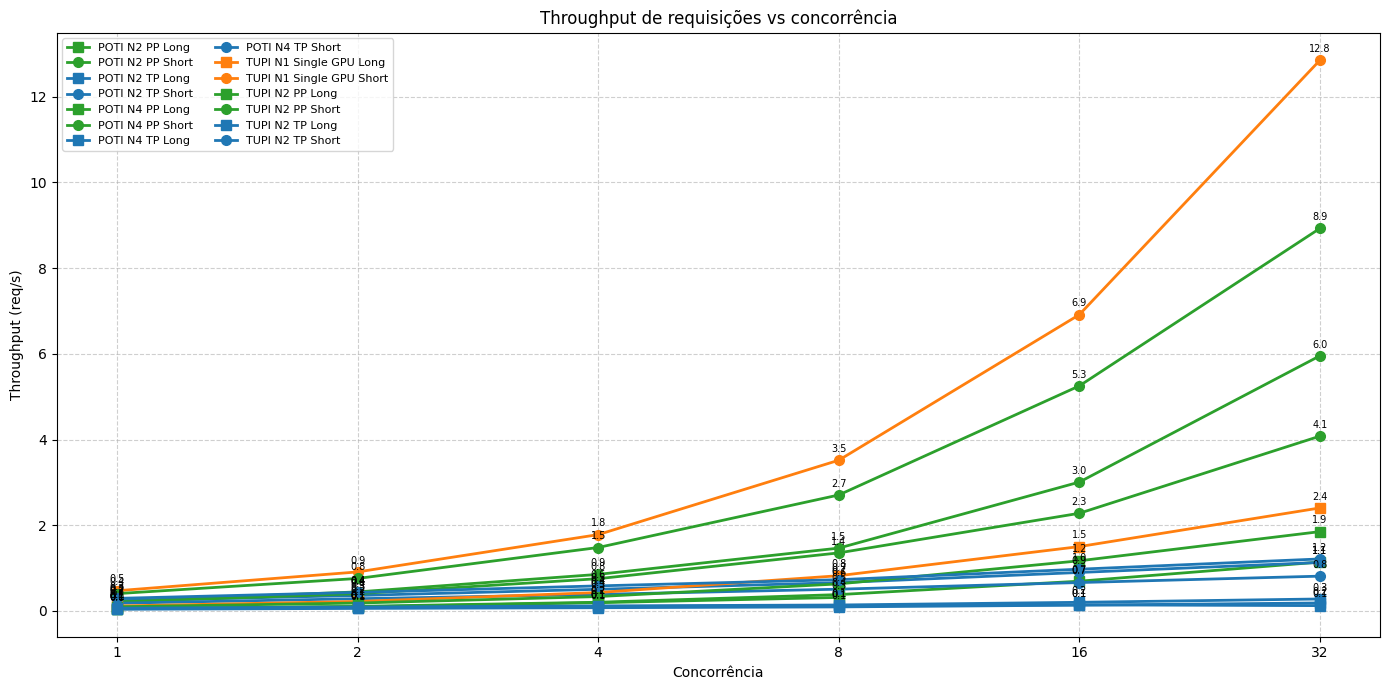

Saved: ../figures/concurrency_analysis/scaling-request-throughput.png


In [8]:
plot_scaling('request_throughput', 'Throughput (req/s)',
             title='Throughput de requisições vs concorrência',
             filename='scaling-request-throughput.png')

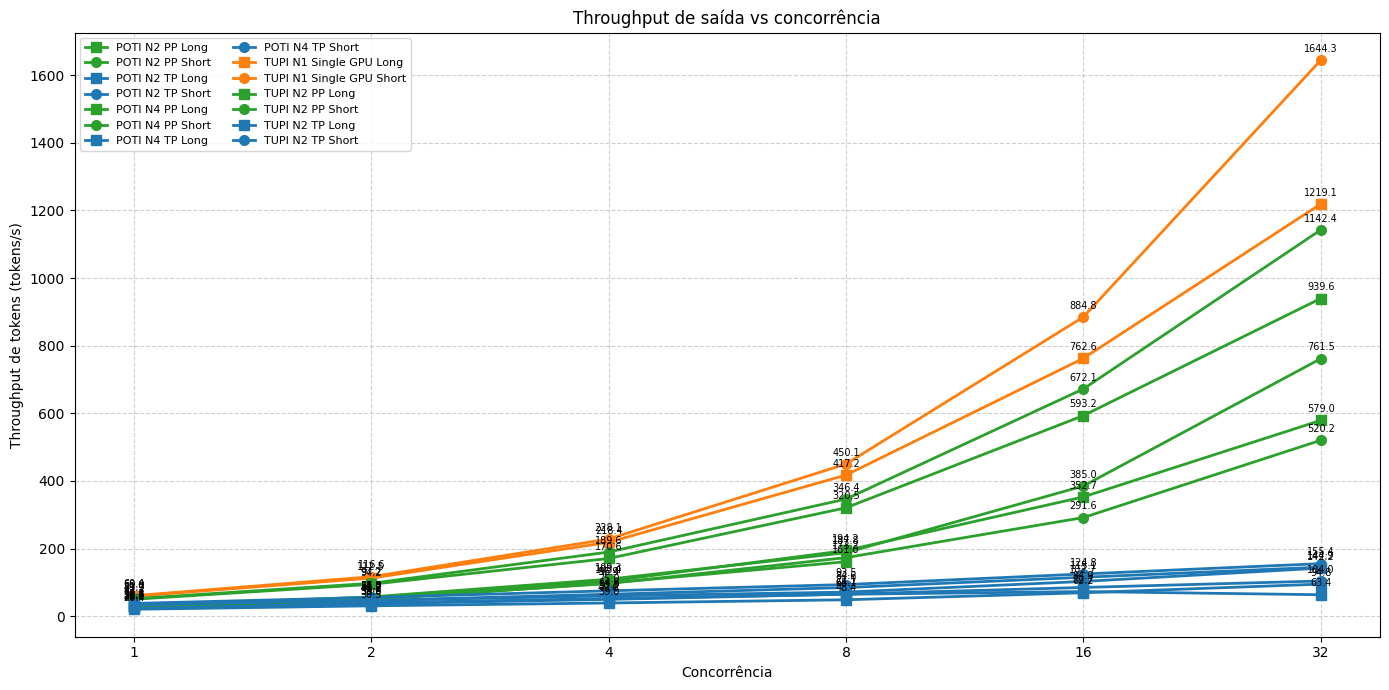

Saved: ../figures/concurrency_analysis/scaling-output-token-throughput.png


In [9]:
plot_scaling('output_token_throughput', 'Throughput de tokens (tokens/s)',
             title='Throughput de saída vs concorrência',
             filename='scaling-output-token-throughput.png')

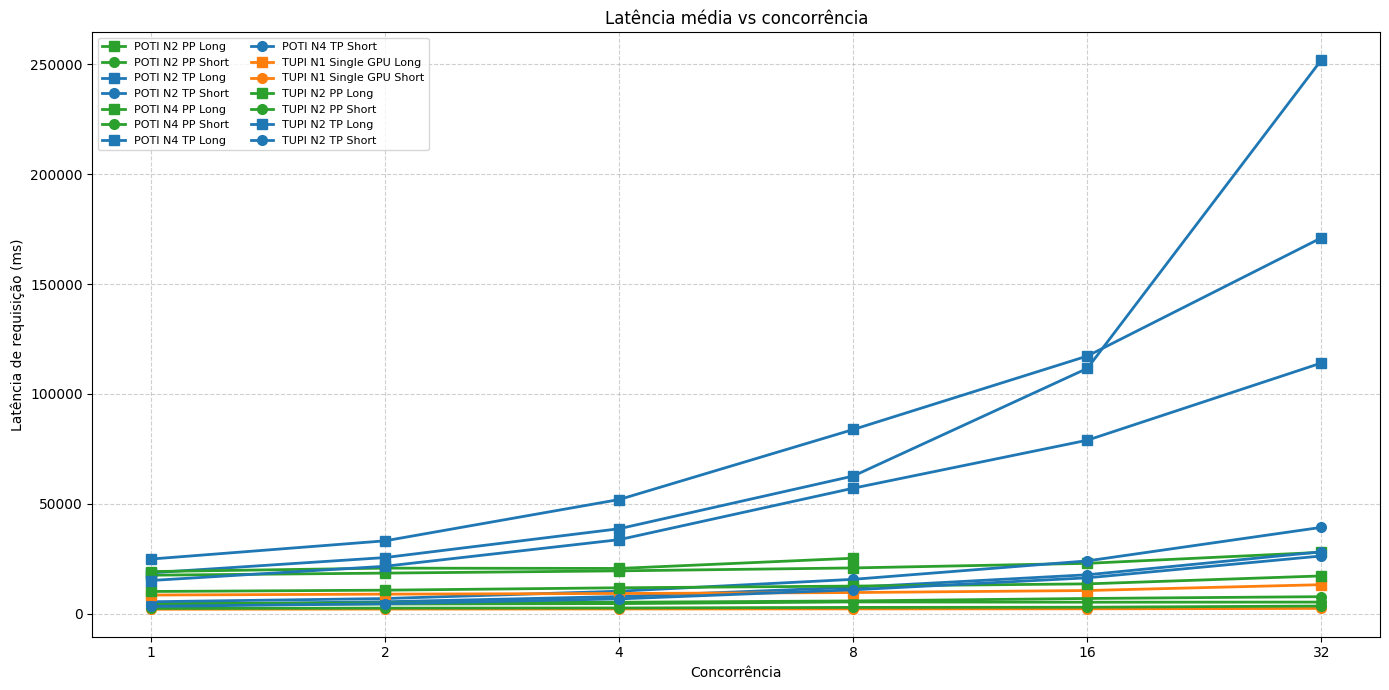

Saved: ../figures/concurrency_analysis/scaling-request-latency.png


In [10]:
plot_scaling('request_latency_avg', 'Latência de requisição (ms)',
             title='Latência média vs concorrência',
             log_y=False, annotate=False,
             filename='scaling-request-latency.png')

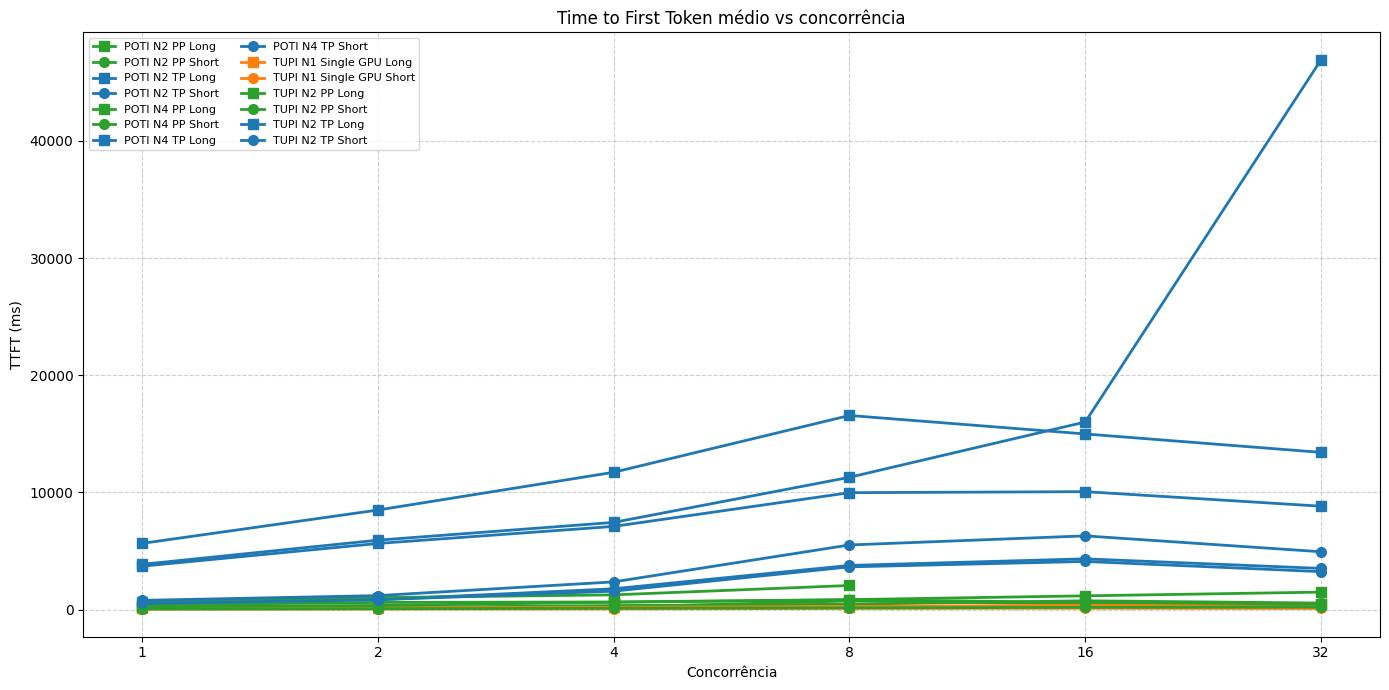

Saved: ../figures/concurrency_analysis/scaling-ttft.png


In [11]:
plot_scaling('ttft_avg', 'TTFT (ms)',
             title='Time to First Token médio vs concorrência',
             annotate=False,
             filename='scaling-ttft.png')

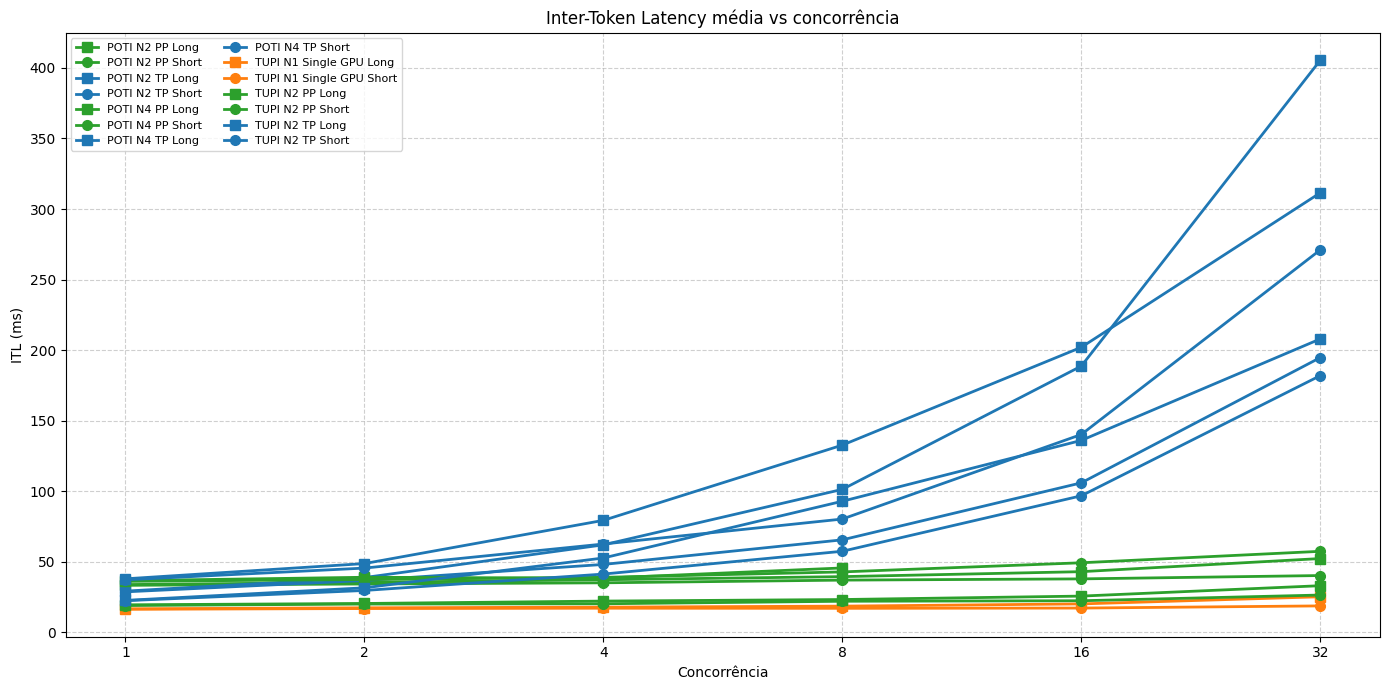

Saved: ../figures/concurrency_analysis/scaling-inter-token-latency.png


In [12]:
plot_scaling('inter_token_latency_avg', 'ITL (ms)',
             title='Inter-Token Latency média vs concorrência',
             annotate=False,
             filename='scaling-inter-token-latency.png')

Enquanto o TTFT permance relativamente estável, todas as outras métricas tendem a aumentar com o aumento da concorrência. No ITL, a estratégia TP de paralelismo mostra um crescimento quase linear, enquanto os outros permancem quase constante. O throughput do TP permance quase constante, enquanto que os das outras estratégias cresce para acomodar a demanda. Todos esses efeitos somados podem ser vistos na latência de requisição, na qual os experimentos que usam TP apresentam uma latência crescente, enquanto que os outros conseguem responder melhor à demanda aumentada.

### Throughput vs latência (Hiperbóide de saturação)

Cada curva plota os pontos `(latência, throughput)` percorridos ao variar a concorrência. O ponto onde o throughput para de crescer marca a saturação do sistema.

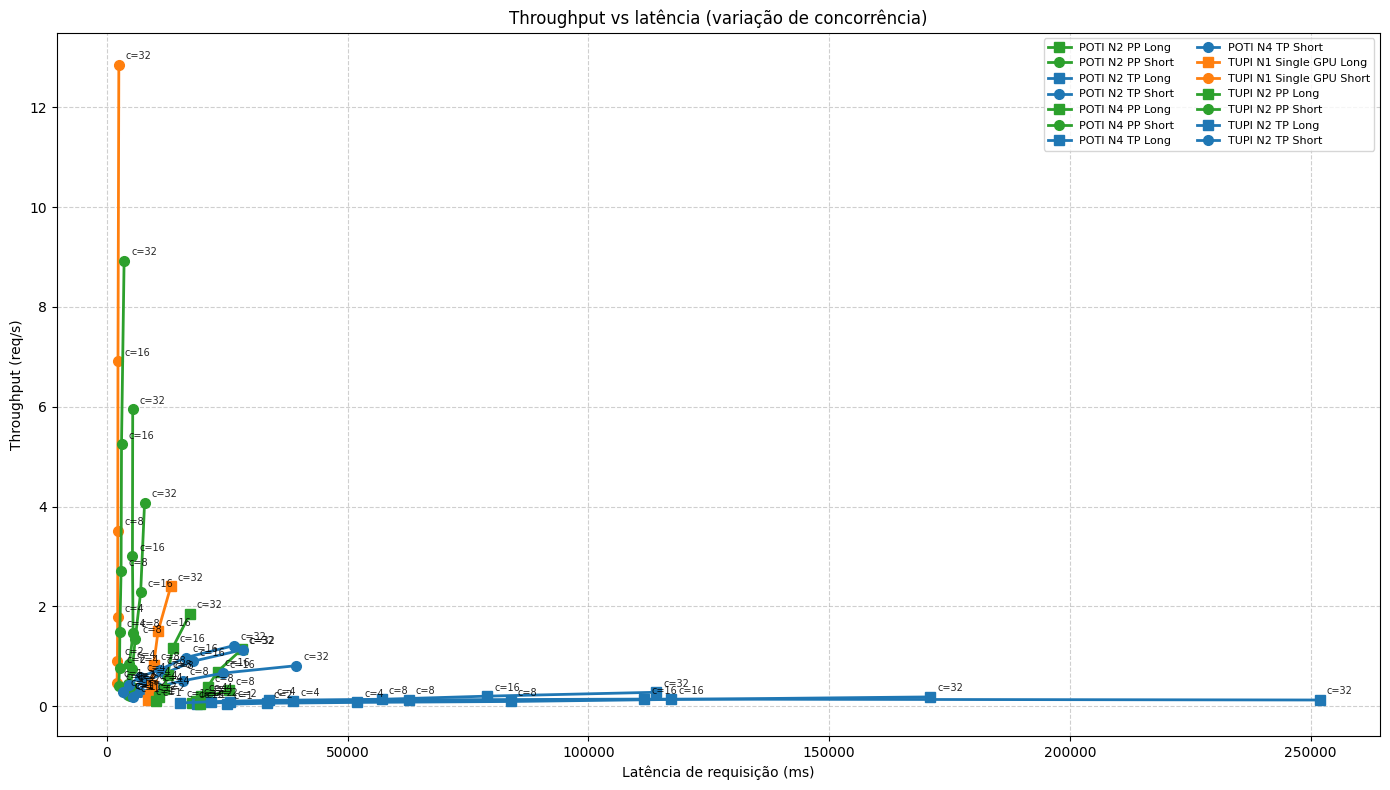

Saved: ../figures/concurrency_analysis/throughput-vs-latency.png


In [13]:
fig, ax = plt.subplots(figsize=(14, 8))

for label, sub in df.groupby('label'):
    sub = sub.sort_values('concurrency').dropna(
        subset=['request_latency_avg', 'request_throughput'])
    if sub.empty:
        continue

    strat   = sub['parallelism'].iloc[0]
    wl      = sub['workload'].iloc[0]
    color   = strategy_color(strat)
    marker  = WORKLOAD_MARKERS.get(wl, 'o')

    ax.plot(sub['request_latency_avg'], sub['request_throughput'],
            marker=marker, color=color, linewidth=2, markersize=7, label=label)

    for _, row in sub.iterrows():
        ax.annotate(f"c={int(row['concurrency'])}",
                    (row['request_latency_avg'], row['request_throughput']),
                    textcoords='offset points', xytext=(5, 4),
                    fontsize=7, alpha=0.85)

ax.set_xlabel('Latência de requisição (ms)')
ax.set_ylabel('Throughput (req/s)')
ax.set_title('Throughput vs latência (variação de concorrência)')
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='best', fontsize=8, ncol=2)
plt.tight_layout()
save_figure('throughput-vs-latency.png')

### Throughput por usuário (eficiência)

`output_token_throughput_per_user` mede quão rápido cada usuário recebe seus tokens em regime compartilhado. Cai when o sistema está sobrecarregado.

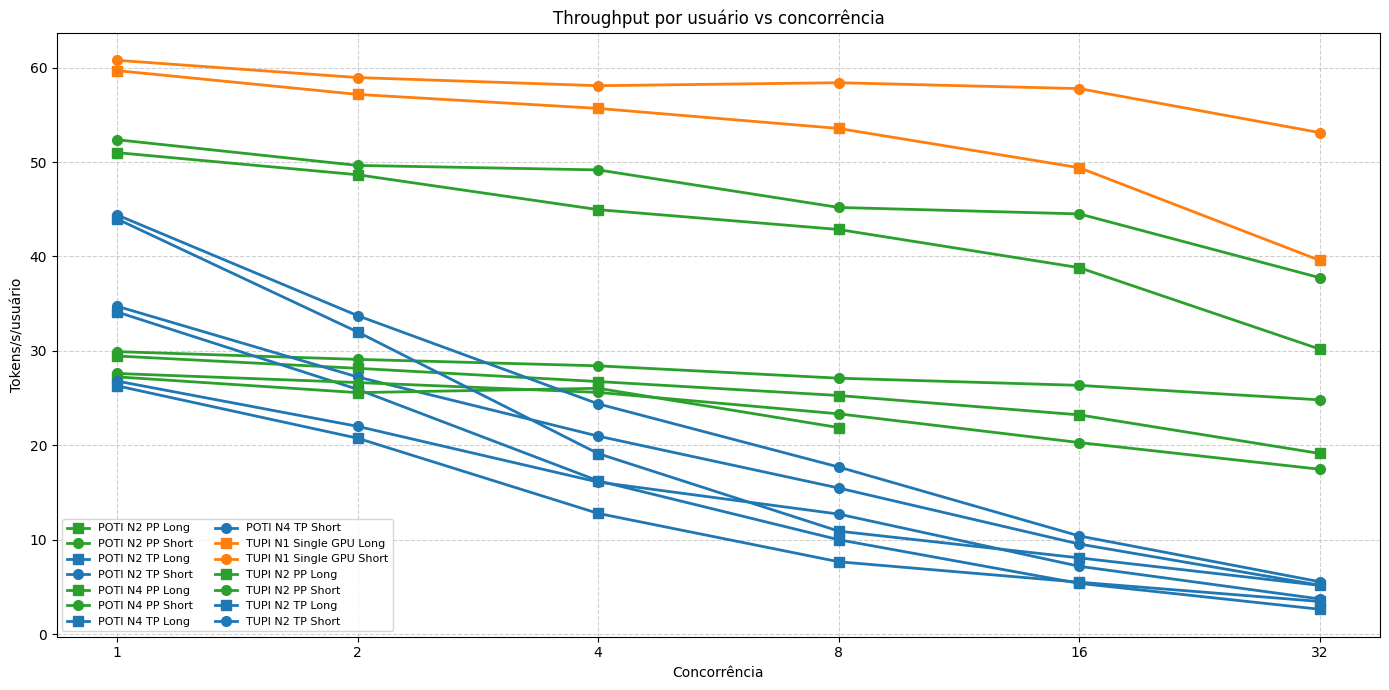

Saved: ../figures/concurrency_analysis/scaling-throughput-per-user.png


In [14]:
plot_scaling('output_token_throughput_user', 'Tokens/s/usuário',
             title='Throughput por usuário vs concorrência',
             annotate=False,
             filename='scaling-throughput-per-user.png')

Corroborando ainda mais com a observação anterior, a eficiência nos processos TP despencam a medida que o número de usuários aumentam.

### Painel em grade (uma subfigura por métrica)

Compara todas as métricas-chave em uma única figura para inspeção rápida.

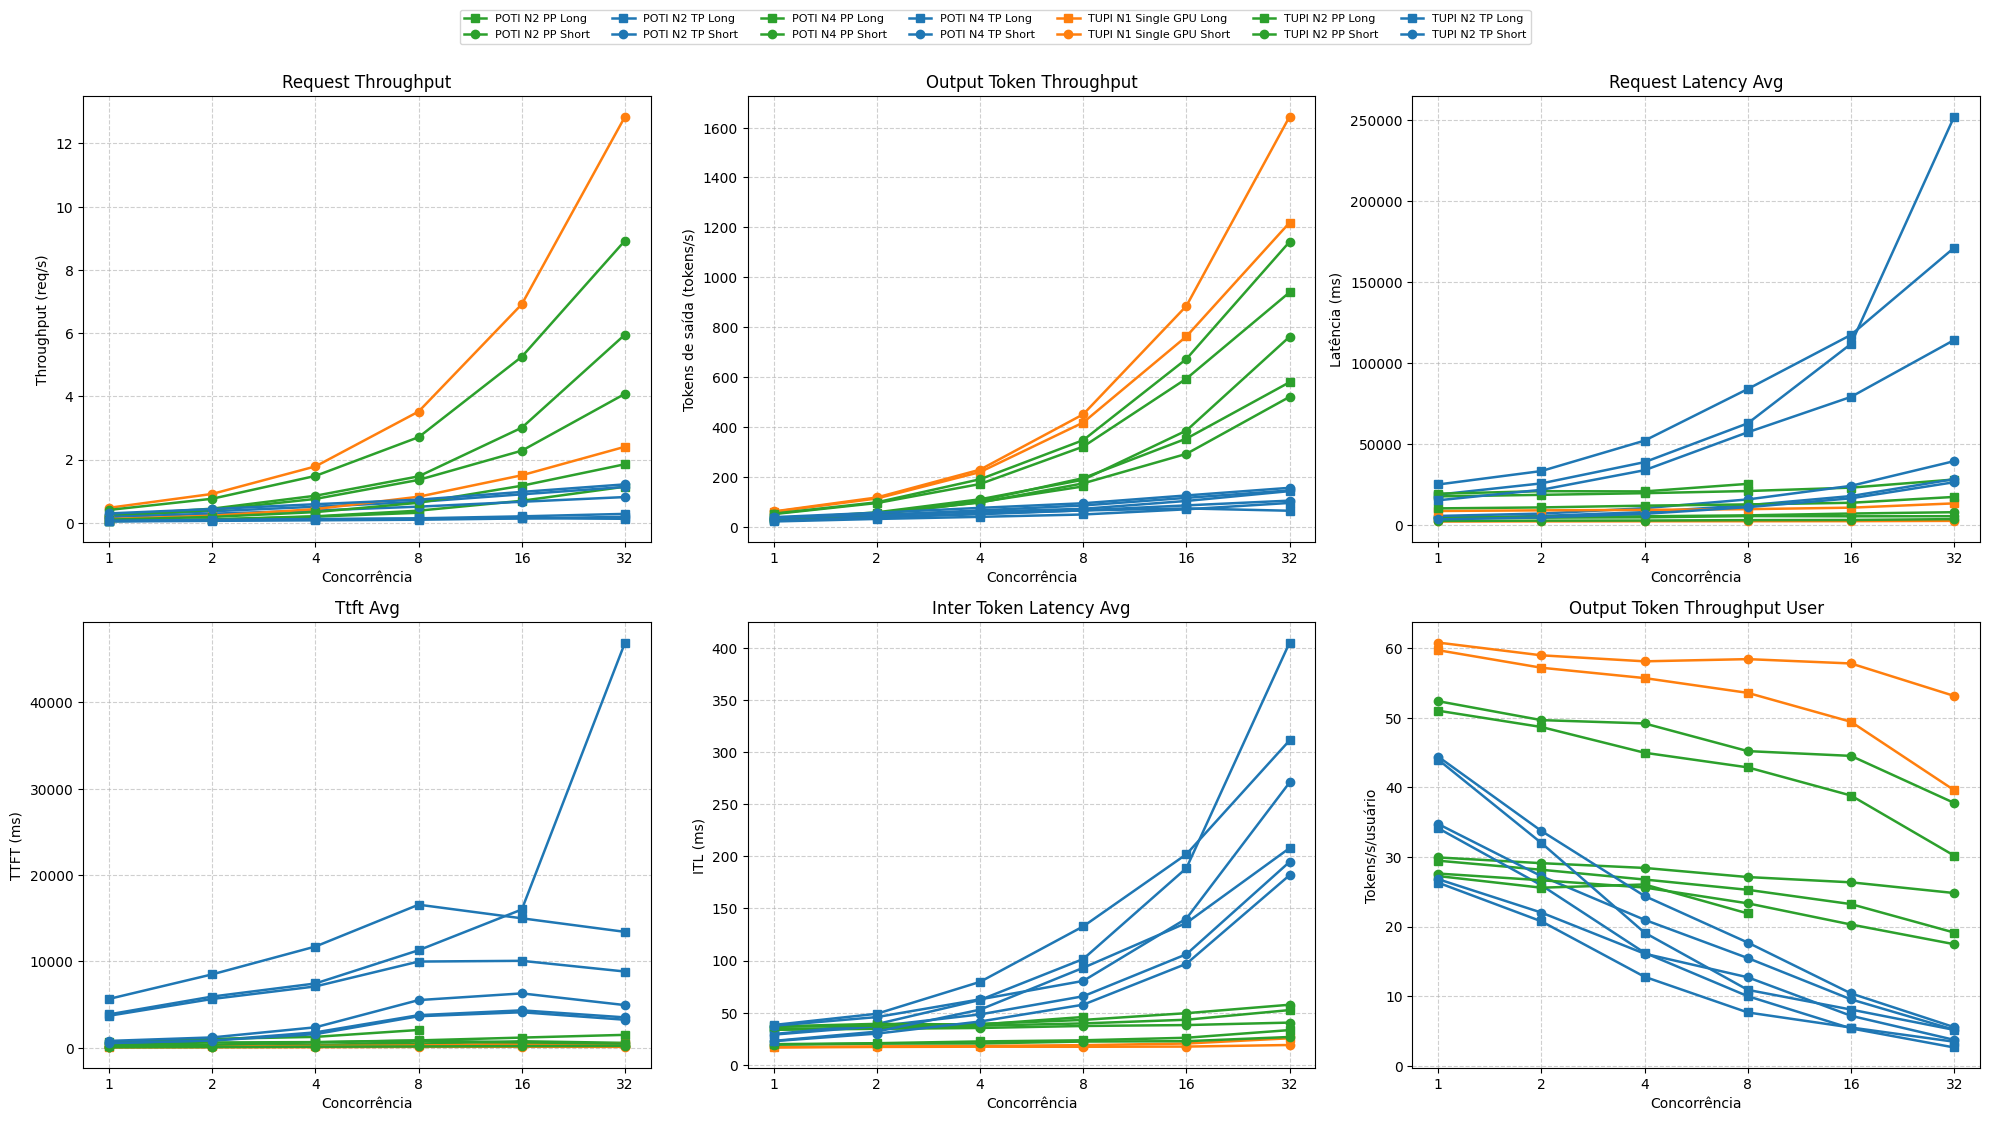

Saved: ../figures/concurrency_analysis/scaling-overview-grid.png


In [15]:
metrics = [
    ('request_throughput',     'Throughput (req/s)'),
    ('output_token_throughput','Tokens de saída (tokens/s)'),
    ('request_latency_avg',    'Latência (ms)'),
    ('ttft_avg',                'TTFT (ms)'),
    ('inter_token_latency_avg', 'ITL (ms)'),
    ('output_token_throughput_user','Tokens/s/usuário'),
]

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes = axes.flatten()

for ax, (metric_col, ylabel) in zip(axes, metrics):
    for label, sub in df.groupby('label'):
        sub = sub.sort_values('concurrency')
        strat   = sub['parallelism'].iloc[0]
        wl      = sub['workload'].iloc[0]
        color   = strategy_color(strat)
        marker  = WORKLOAD_MARKERS.get(wl, 'o')
        ax.plot(sub['concurrency'], sub[metric_col],
                marker=marker, color=color, linewidth=1.8, markersize=6,
                label=label)

    ax.set_xscale('log', base=2)
    ax.set_xticks(sorted(df['concurrency'].unique()))
    ax.set_xticklabels(sorted(df['concurrency'].unique()))
    ax.set_xlabel('Concorrência')
    ax.set_ylabel(ylabel)
    ax.set_title(pretty_metric_name(metric_col))
    ax.grid(True, which='both', linestyle='--', alpha=0.6)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center',
           bbox_to_anchor=(0.5, 1.02), ncol=7, fontsize=8)
plt.tight_layout(rect=(0, 0, 1, 0.97))
save_figure('scaling-overview-grid.png')

### Painel por cluster (slides "Concorrencia Tupi/Poti" da apresentação final)

Mesmas 4 métricas dos slides de métricas de inferência, agora em função do **nível de
concorrência** (eixo x, log₂): uma linha por job (nº de nós × estratégia × workload),
cor pela estratégia, tracejado = short, sólido = long, marcador pelo nº de nós.
Latência e TTFT em escala log no eixo y (short e long diferem em ordem de grandeza).


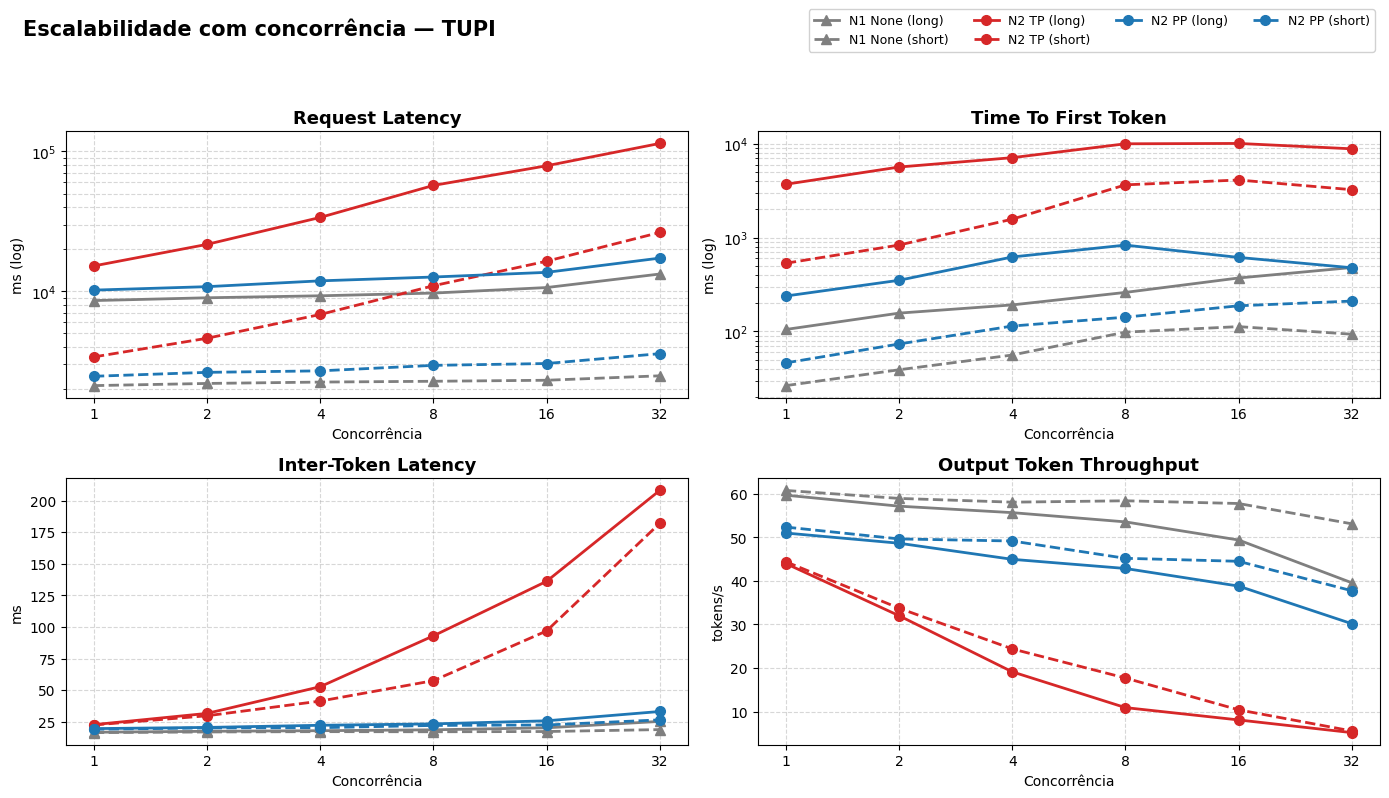

Saved: ../figures/concurrency_analysis/scaling-cluster-tupi.png


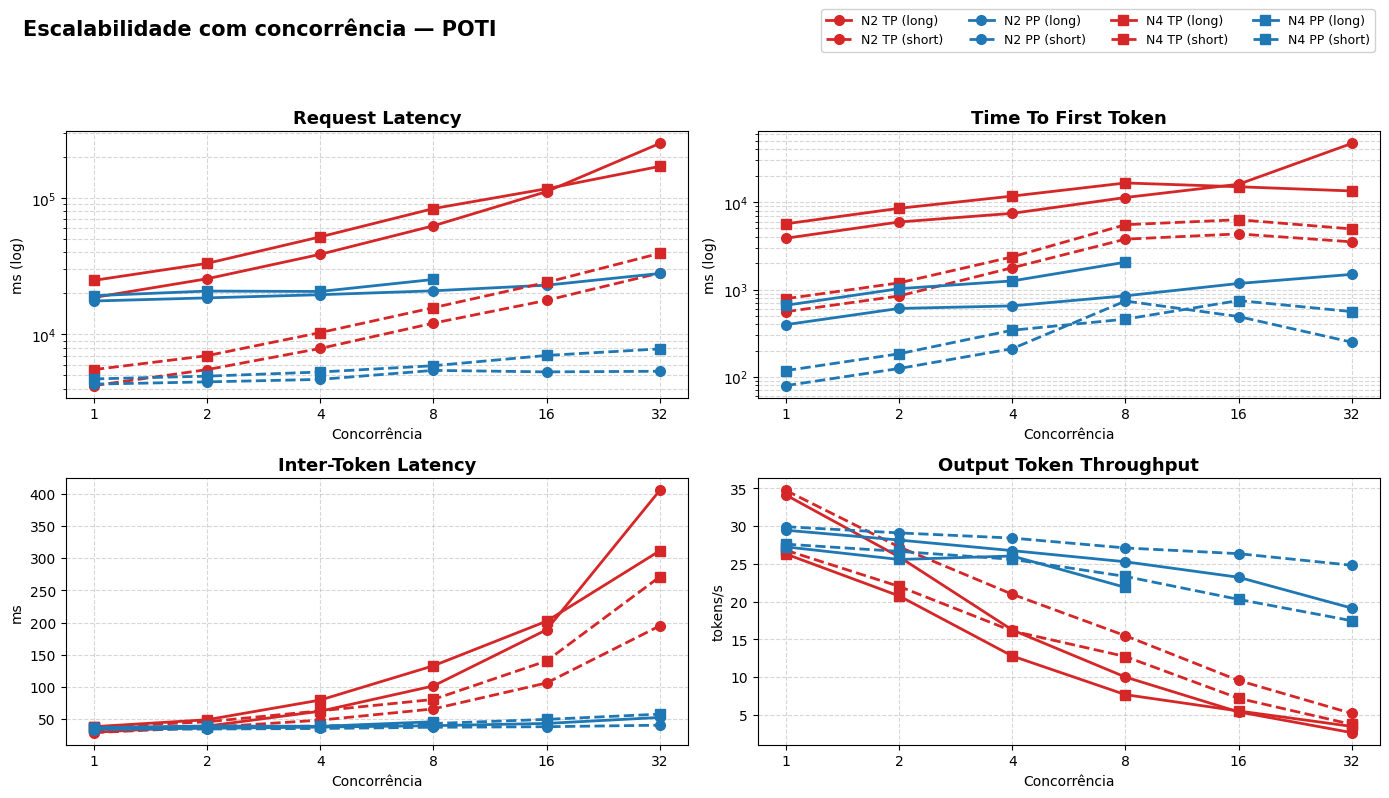

Saved: ../figures/concurrency_analysis/scaling-cluster-poti.png


In [16]:
cluster_panel_metrics = {
    'request_latency_avg':          ('Request Latency', 'ms', True),
    'ttft_avg':                     ('Time To First Token', 'ms', True),
    'inter_token_latency_avg':      ('Inter-Token Latency', 'ms', False),
    'output_token_throughput_user': ('Output Token Throughput', 'tokens/s', False),
}

NODE_MARKERS_CLUSTER = {1: '^', 2: 'o', 4: 's'}
STRAT_RANK = {'Single GPU': 0, 'TP': 1, 'PP': 2}
# Paleta dos slides de métricas (9-10), para consistência dentro da apresentação
CLUSTER_PANEL_COLORS = {'Single GPU': 'tab:gray', 'TP': 'tab:red', 'PP': 'tab:blue'}


def plot_cluster_concurrency(cluster):
    cdf = df[df['node'] == cluster].copy()
    if cdf.empty:
        print(f'Sem dados para {cluster}.')
        return

    conc_levels = sorted(cdf['concurrency'].unique())
    groups = sorted(
        cdf.groupby(['n_gpus', 'parallelism', 'workload']),
        key=lambda kv: (kv[0][0], STRAT_RANK.get(kv[0][1], 9), kv[0][2]),
    )

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    axes = axes.flatten()

    for idx, (metric, (title, unit, log_y)) in enumerate(cluster_panel_metrics.items()):
        ax = axes[idx]
        for (n, strat, wl), sub in groups:
            sub = sub.sort_values('concurrency')
            strat_label = 'None' if strat == 'Single GPU' else strat
            ax.plot(sub['concurrency'], sub[metric],
                    color=CLUSTER_PANEL_COLORS.get(strat, 'tab:gray'),
                    marker=NODE_MARKERS_CLUSTER.get(n, 'o'),
                    linestyle='-' if wl == 'long' else '--',
                    linewidth=2, markersize=7,
                    label=f'N{n} {strat_label} ({wl})')

        ax.set_xscale('log', base=2)
        ax.set_xticks(conc_levels)
        ax.set_xticklabels(conc_levels)
        if log_y:
            ax.set_yscale('log')
        ax.set_xlabel('Concorrência')
        ax.set_ylabel(f'{unit} (log)' if log_y else unit)
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.grid(True, which='both', linestyle='--', alpha=0.5)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.99, 1.0),
               ncol=4, fontsize=9, framealpha=0.9)

    fig.suptitle(f'Escalabilidade com concorrência — {cluster.upper()}',
                 fontsize=15, fontweight='bold', x=0.02, ha='left')
    fig.tight_layout(rect=[0, 0, 1, 0.93])

    save_figure(f'scaling-cluster-{cluster}.png')


for cluster in ['tupi', 'poti']:
    plot_cluster_concurrency(cluster)


### Comparação lado a lado por workload

Para cada workload (short/long), separa os experimentos e plota a latência vs throughput junto, evidenciando onde cada configuração satura.

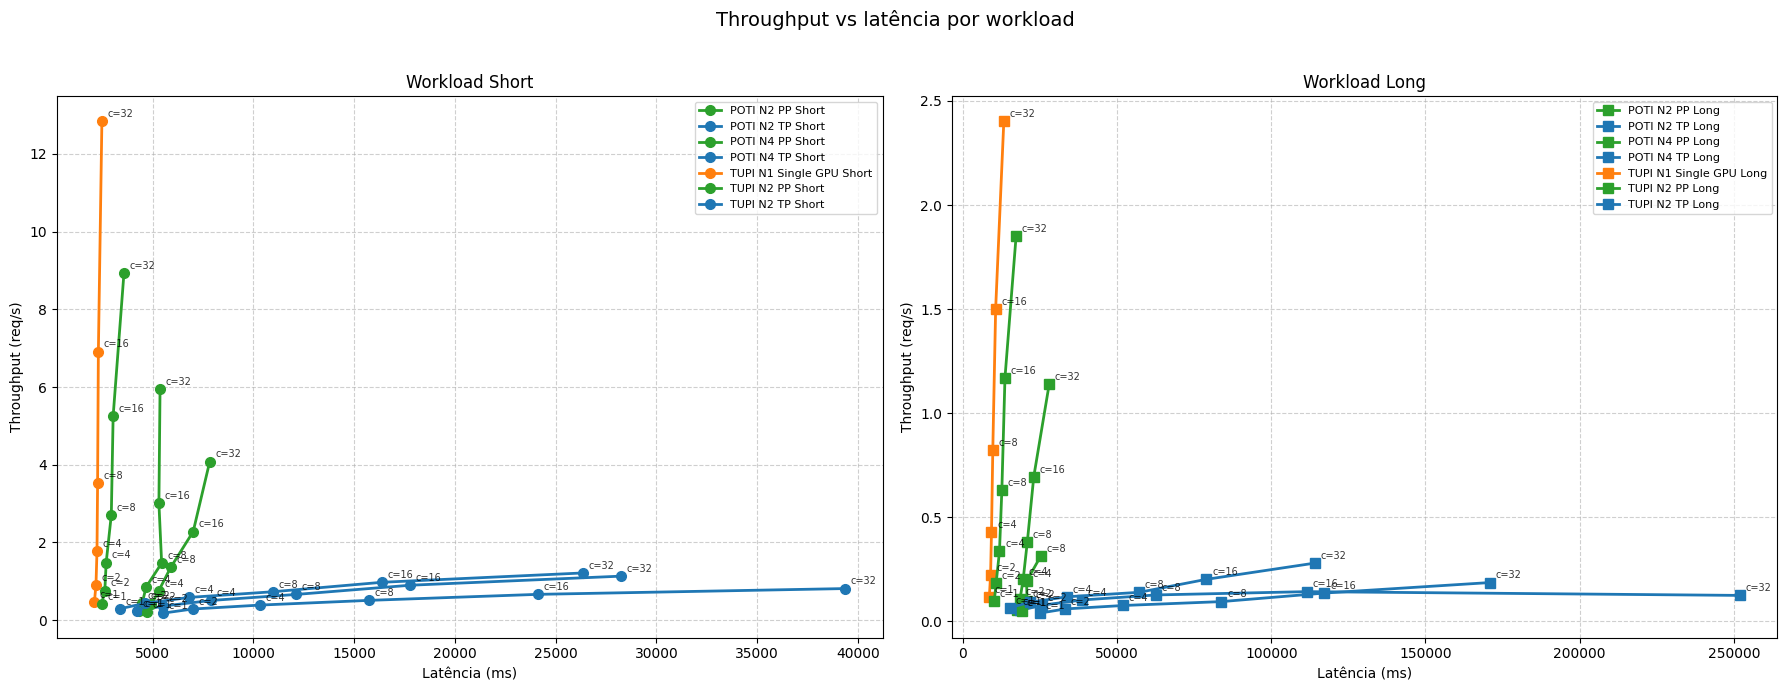

Saved: ../figures/concurrency_analysis/throughput-vs-latency-by-workload.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=False)

for ax, wl in zip(axes, WORKLOAD_ORDER):
    sub = df[df['workload'] == wl]
    for label, g in sub.groupby('label'):
        g = g.sort_values('concurrency').dropna(
            subset=['request_latency_avg', 'request_throughput'])
        if g.empty:
            continue
        strat  = g['parallelism'].iloc[0]
        color  = strategy_color(strat)
        marker = WORKLOAD_MARKERS.get(wl, 'o')
        ax.plot(g['request_latency_avg'], g['request_throughput'],
                marker=marker, color=color, linewidth=2, markersize=7,
                label=label)

        for _, row in g.iterrows():
            ax.annotate(f"c={int(row['concurrency'])}",
                        (row['request_latency_avg'], row['request_throughput']),
                        textcoords='offset points', xytext=(4, 3),
                        fontsize=7, alpha=0.8)

    ax.set_xlabel('Latência (ms)')
    ax.set_ylabel('Throughput (req/s)')
    ax.set_title(f'Workload {wl.capitalize()}')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='best', fontsize=8)

fig.suptitle('Throughput vs latência por workload', fontsize=14)
plt.tight_layout(rect=(0, 0, 1, 0.96))
save_figure('throughput-vs-latency-by-workload.png')

### Distribuição por requisição por nível de concorrência

Lê o `profile_export.jsonl` de cada nível e mostra a distribuição da latência de requisição (boxplot) para alguns experimentos representativos. Isso revela a variabilidade que as médias escondem em alta concorrência.

/tmp/nix-shell.U9xriO/ipykernel_565746/2745907445.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_lat.boxplot(lat_data, labels=[str(c) for c in concs], showfliers=True)
/tmp/nix-shell.U9xriO/ipykernel_565746/2745907445.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_ttft.boxplot(ttft_data, labels=[str(c) for c in tconcs], showfliers=True)


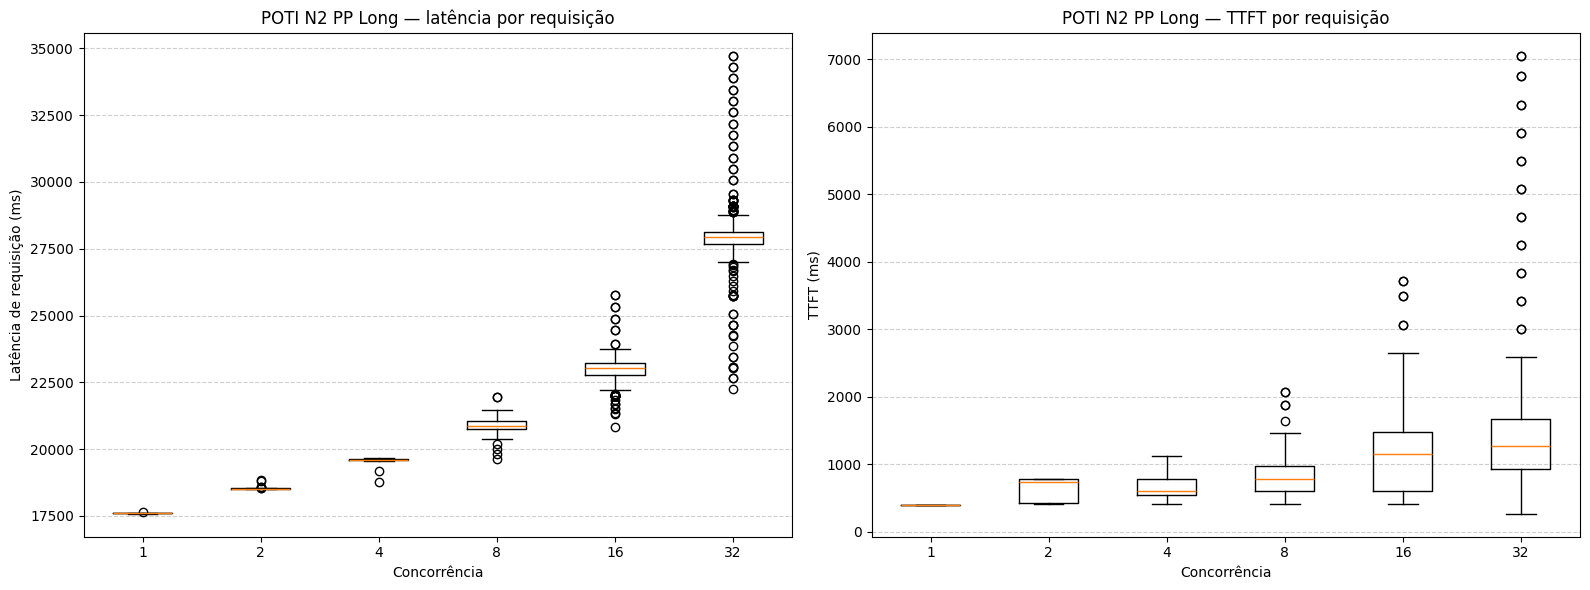

Saved: ../figures/concurrency_analysis/distribution-N2-poti-PP-long-r1-795373.png


/tmp/nix-shell.U9xriO/ipykernel_565746/2745907445.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_lat.boxplot(lat_data, labels=[str(c) for c in concs], showfliers=True)
/tmp/nix-shell.U9xriO/ipykernel_565746/2745907445.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_ttft.boxplot(ttft_data, labels=[str(c) for c in tconcs], showfliers=True)


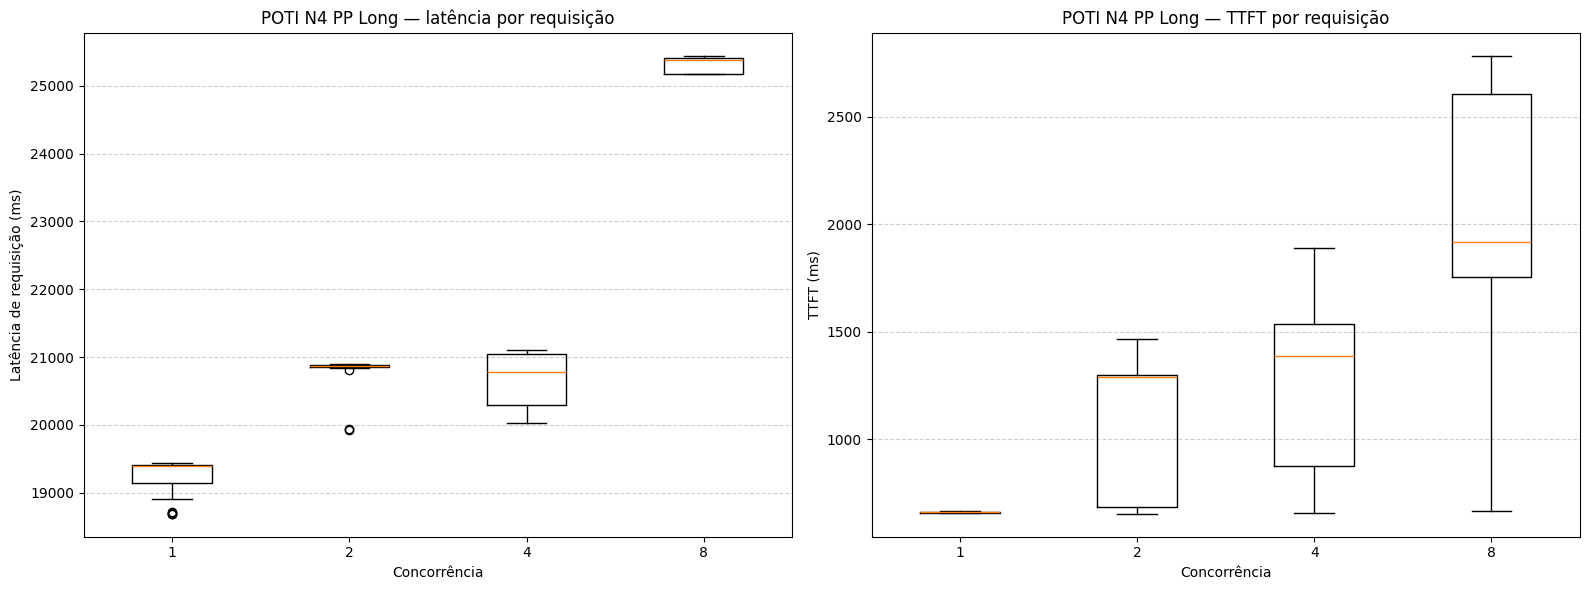

Saved: ../figures/concurrency_analysis/distribution-N4-poti-PP-long-r1-795375.png


/tmp/nix-shell.U9xriO/ipykernel_565746/2745907445.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_lat.boxplot(lat_data, labels=[str(c) for c in concs], showfliers=True)
/tmp/nix-shell.U9xriO/ipykernel_565746/2745907445.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_ttft.boxplot(ttft_data, labels=[str(c) for c in tconcs], showfliers=True)


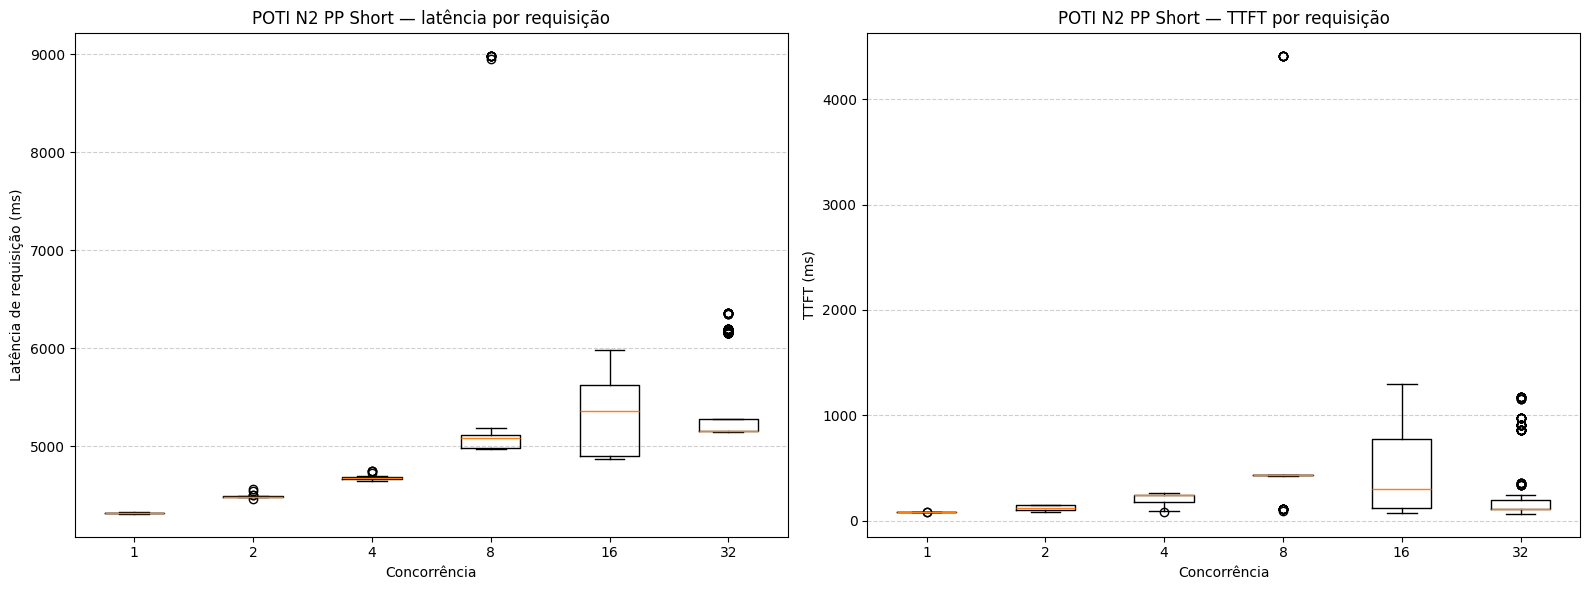

Saved: ../figures/concurrency_analysis/distribution-N2-poti-PP-short-r1-795497.png


/tmp/nix-shell.U9xriO/ipykernel_565746/2745907445.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_lat.boxplot(lat_data, labels=[str(c) for c in concs], showfliers=True)
/tmp/nix-shell.U9xriO/ipykernel_565746/2745907445.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_ttft.boxplot(ttft_data, labels=[str(c) for c in tconcs], showfliers=True)


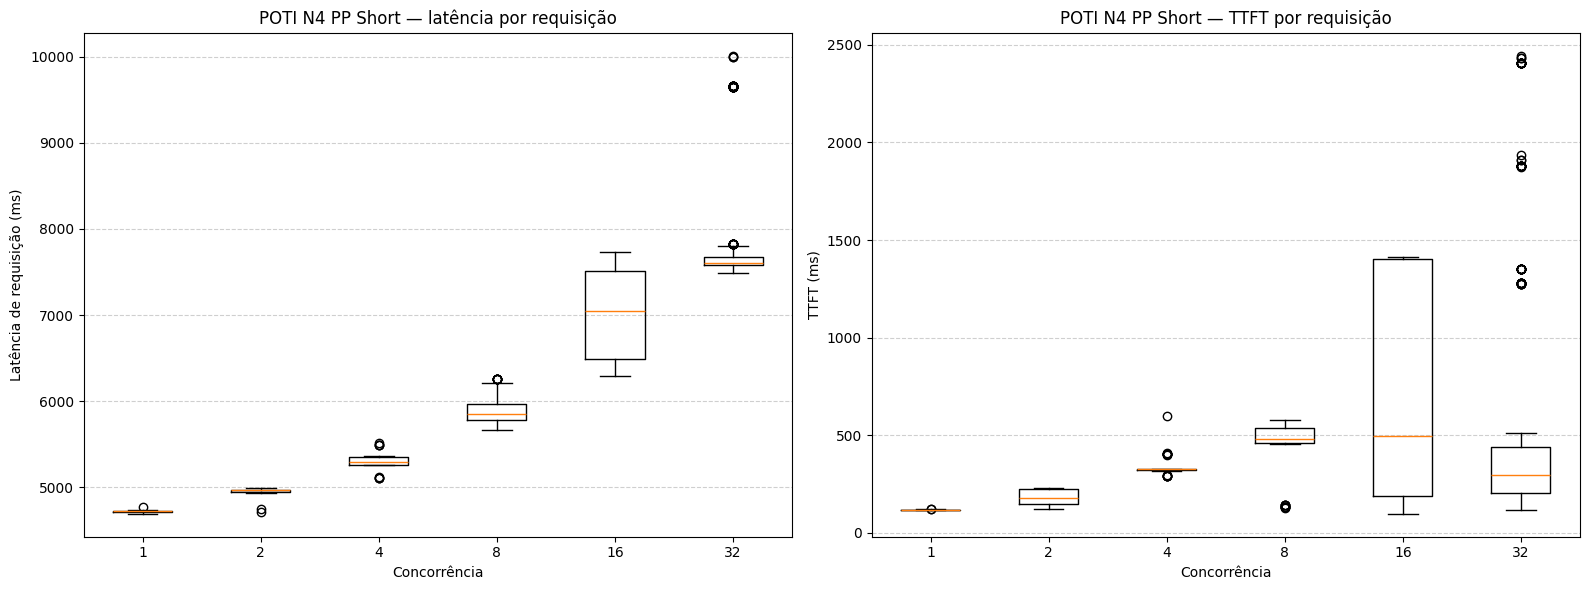

Saved: ../figures/concurrency_analysis/distribution-N4-poti-PP-short-r1-796677.png


/tmp/nix-shell.U9xriO/ipykernel_565746/2745907445.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_lat.boxplot(lat_data, labels=[str(c) for c in concs], showfliers=True)
/tmp/nix-shell.U9xriO/ipykernel_565746/2745907445.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_ttft.boxplot(ttft_data, labels=[str(c) for c in tconcs], showfliers=True)


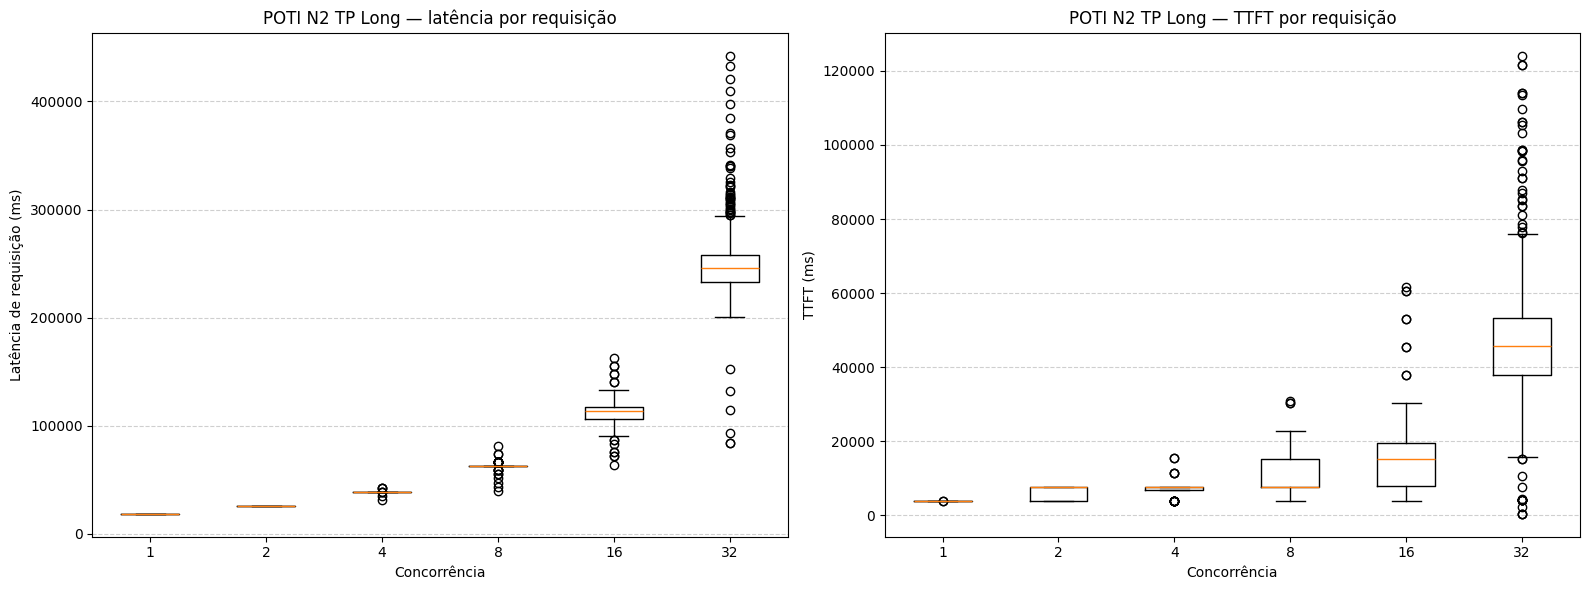

Saved: ../figures/concurrency_analysis/distribution-N2-poti-TP-long-r1-796179.png


/tmp/nix-shell.U9xriO/ipykernel_565746/2745907445.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_lat.boxplot(lat_data, labels=[str(c) for c in concs], showfliers=True)
/tmp/nix-shell.U9xriO/ipykernel_565746/2745907445.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_ttft.boxplot(ttft_data, labels=[str(c) for c in tconcs], showfliers=True)


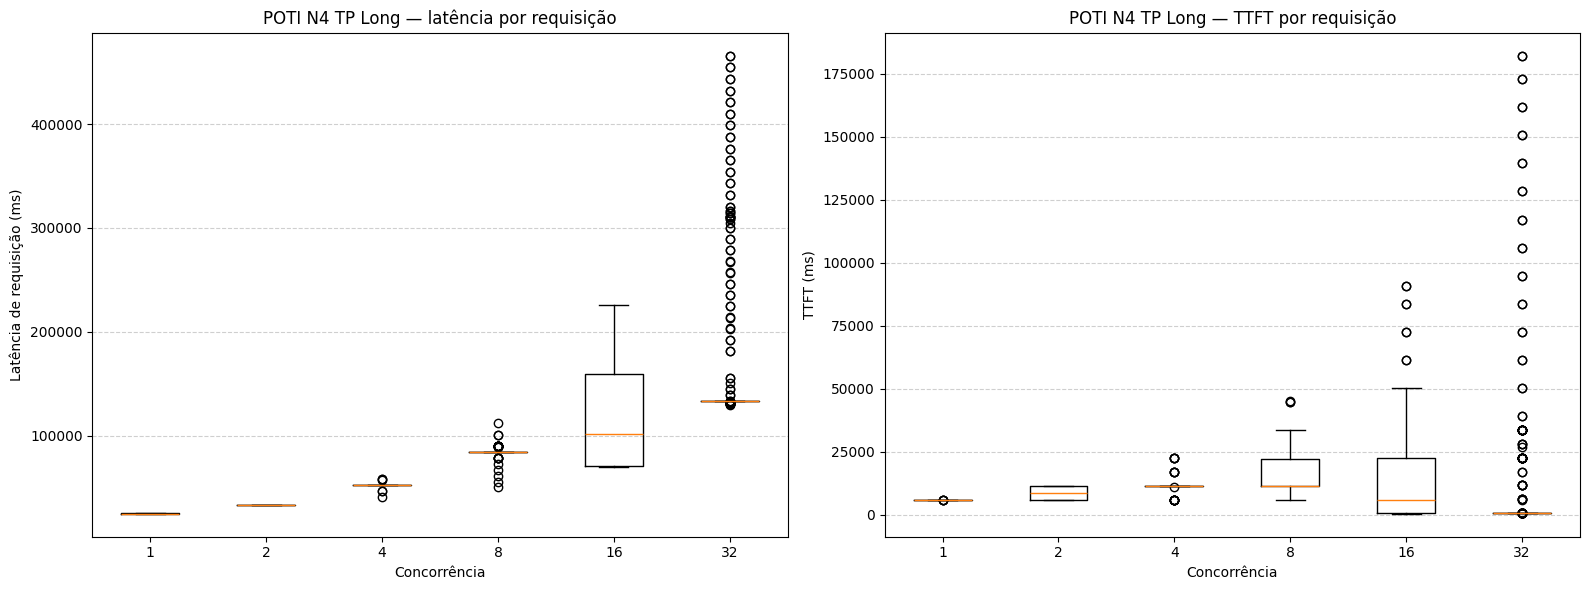

Saved: ../figures/concurrency_analysis/distribution-N4-poti-TP-long-r1-796873.png


/tmp/nix-shell.U9xriO/ipykernel_565746/2745907445.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_lat.boxplot(lat_data, labels=[str(c) for c in concs], showfliers=True)
/tmp/nix-shell.U9xriO/ipykernel_565746/2745907445.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_ttft.boxplot(ttft_data, labels=[str(c) for c in tconcs], showfliers=True)


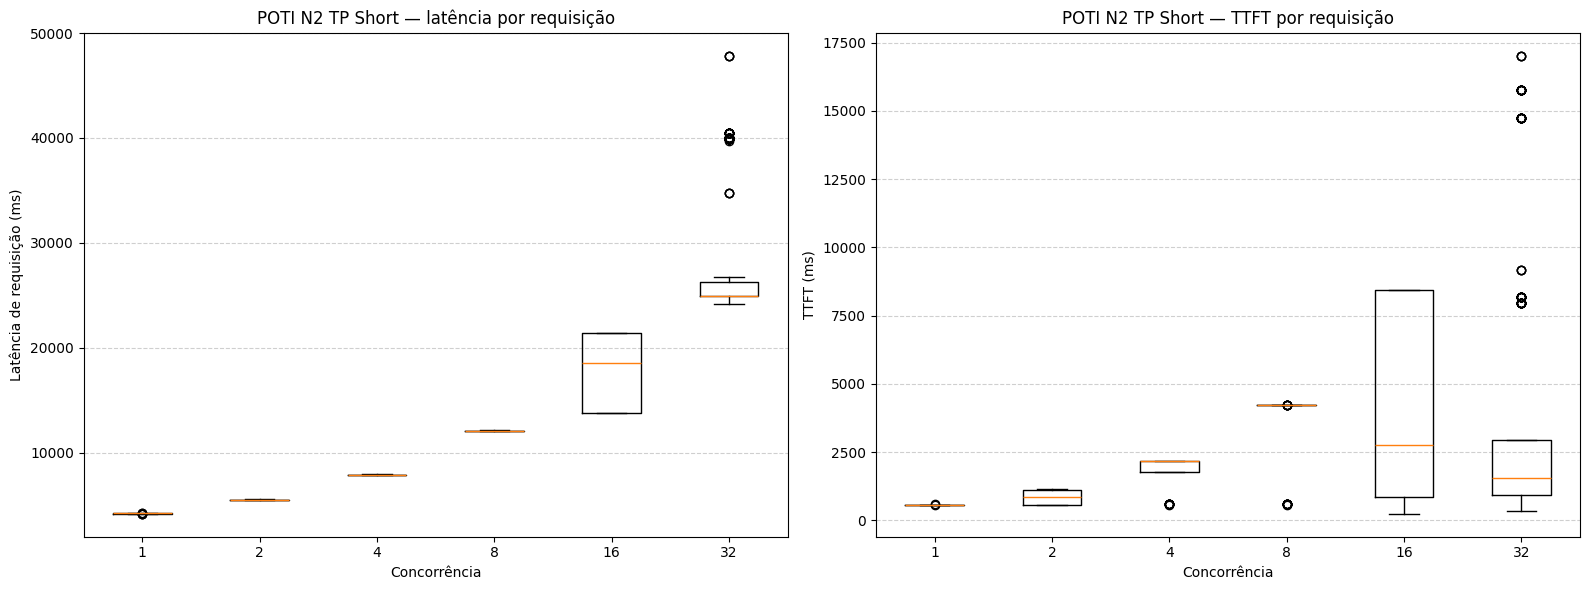

Saved: ../figures/concurrency_analysis/distribution-N2-poti-TP-short-r1-796674.png


/tmp/nix-shell.U9xriO/ipykernel_565746/2745907445.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_lat.boxplot(lat_data, labels=[str(c) for c in concs], showfliers=True)
/tmp/nix-shell.U9xriO/ipykernel_565746/2745907445.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_ttft.boxplot(ttft_data, labels=[str(c) for c in tconcs], showfliers=True)


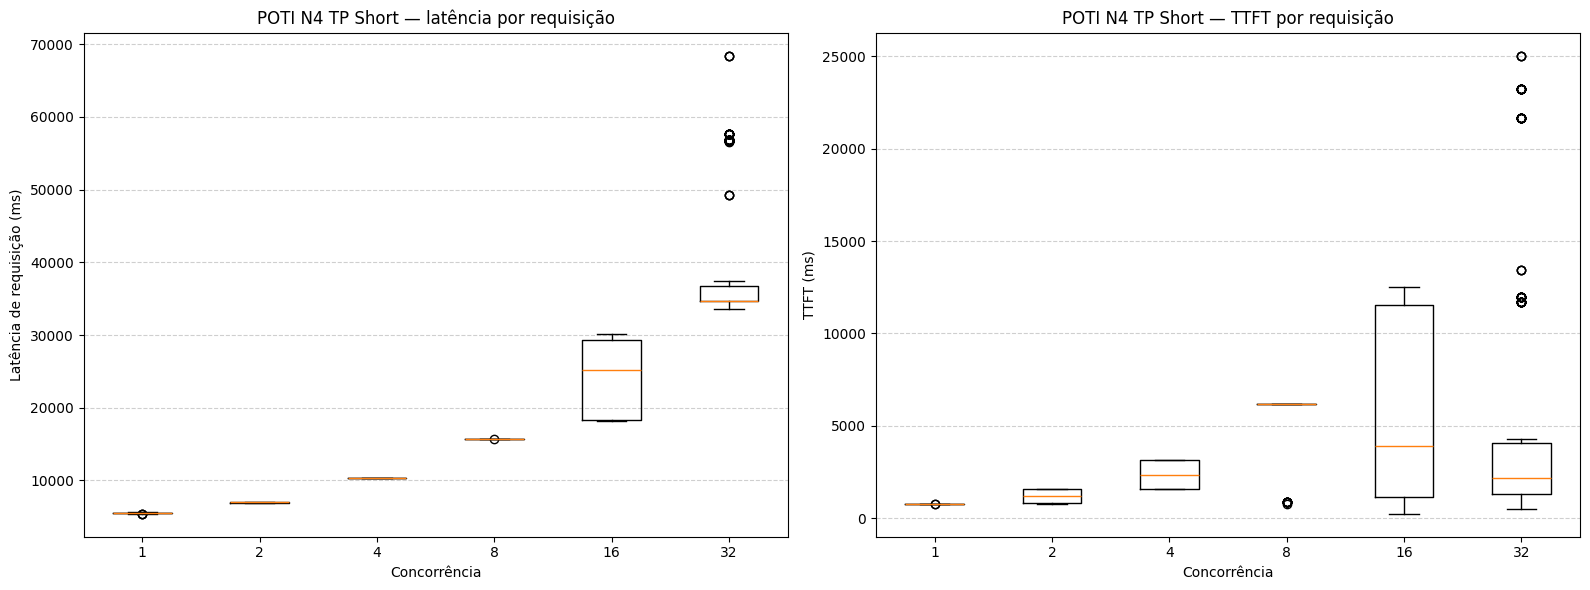

Saved: ../figures/concurrency_analysis/distribution-N4-poti-TP-short-r1-796873.png


/tmp/nix-shell.U9xriO/ipykernel_565746/2745907445.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_lat.boxplot(lat_data, labels=[str(c) for c in concs], showfliers=True)
/tmp/nix-shell.U9xriO/ipykernel_565746/2745907445.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_ttft.boxplot(ttft_data, labels=[str(c) for c in tconcs], showfliers=True)


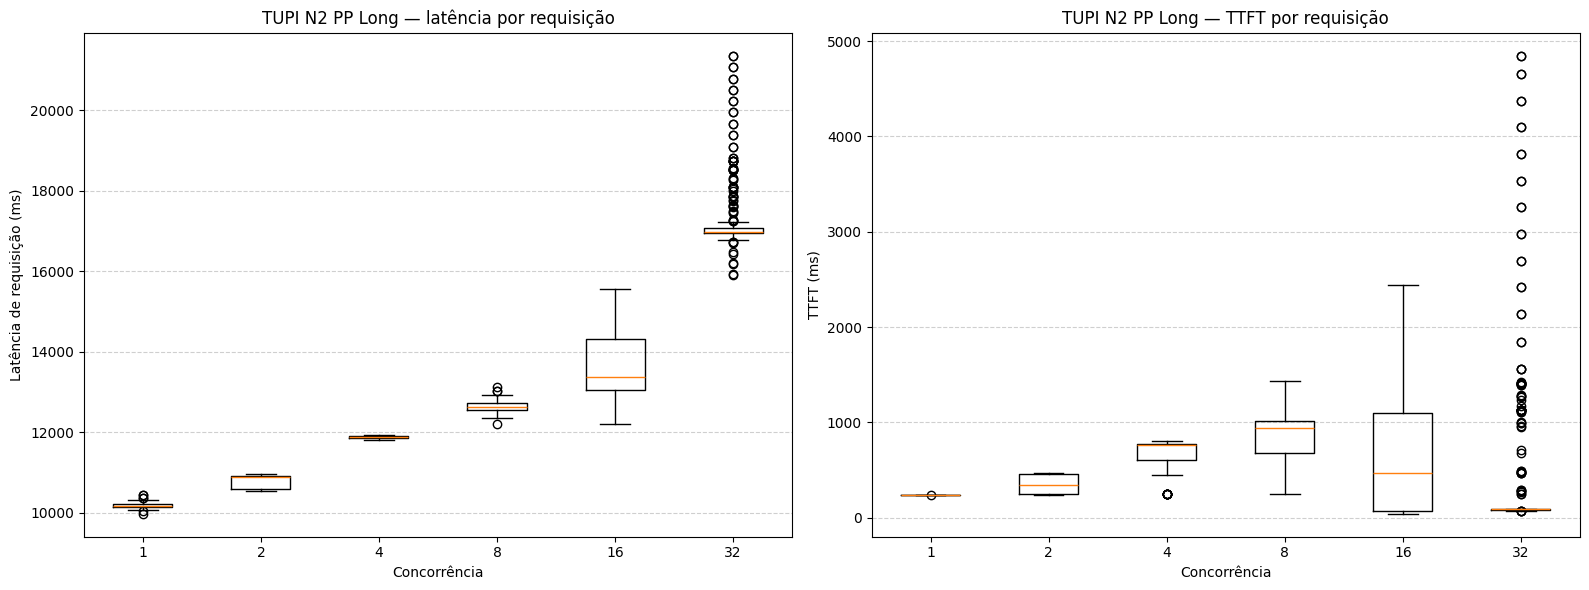

Saved: ../figures/concurrency_analysis/distribution-N2-tupi-PP-long-r1-796872.png


/tmp/nix-shell.U9xriO/ipykernel_565746/2745907445.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_lat.boxplot(lat_data, labels=[str(c) for c in concs], showfliers=True)
/tmp/nix-shell.U9xriO/ipykernel_565746/2745907445.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_ttft.boxplot(ttft_data, labels=[str(c) for c in tconcs], showfliers=True)


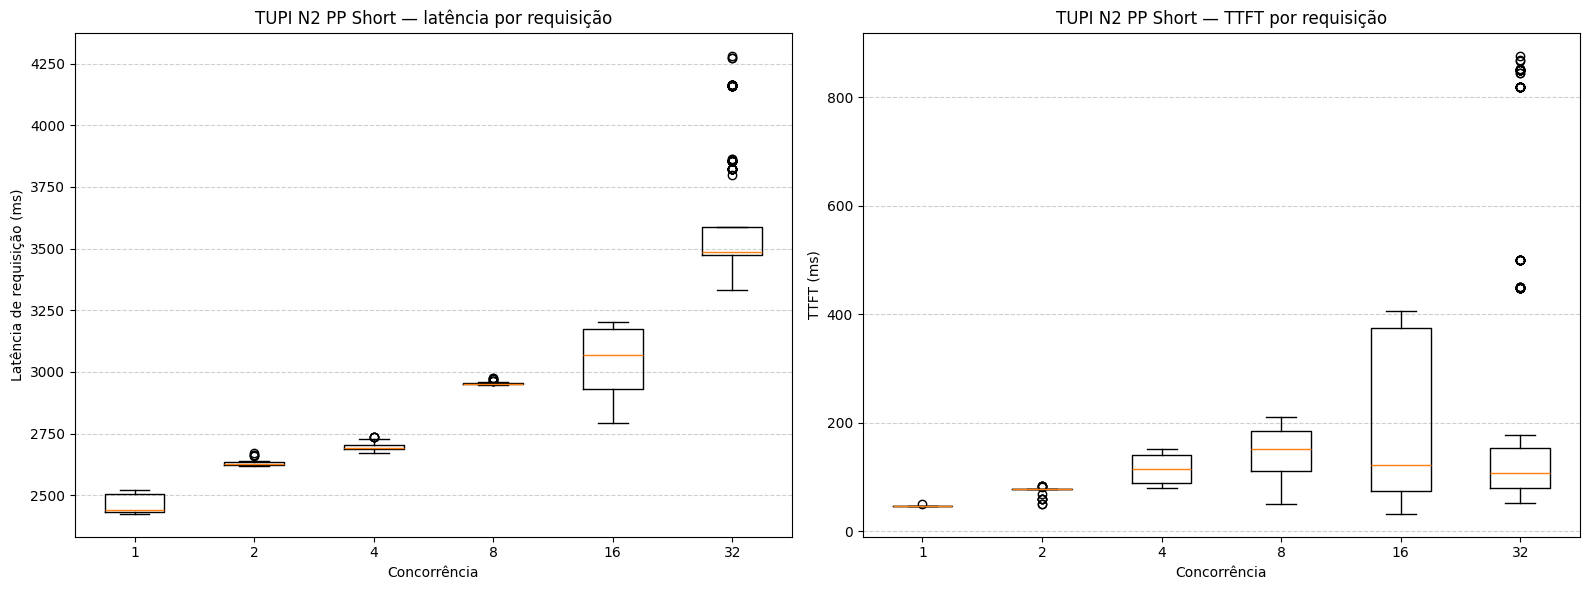

Saved: ../figures/concurrency_analysis/distribution-N2-tupi-PP-short-r1-796872.png


/tmp/nix-shell.U9xriO/ipykernel_565746/2745907445.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_lat.boxplot(lat_data, labels=[str(c) for c in concs], showfliers=True)
/tmp/nix-shell.U9xriO/ipykernel_565746/2745907445.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_ttft.boxplot(ttft_data, labels=[str(c) for c in tconcs], showfliers=True)


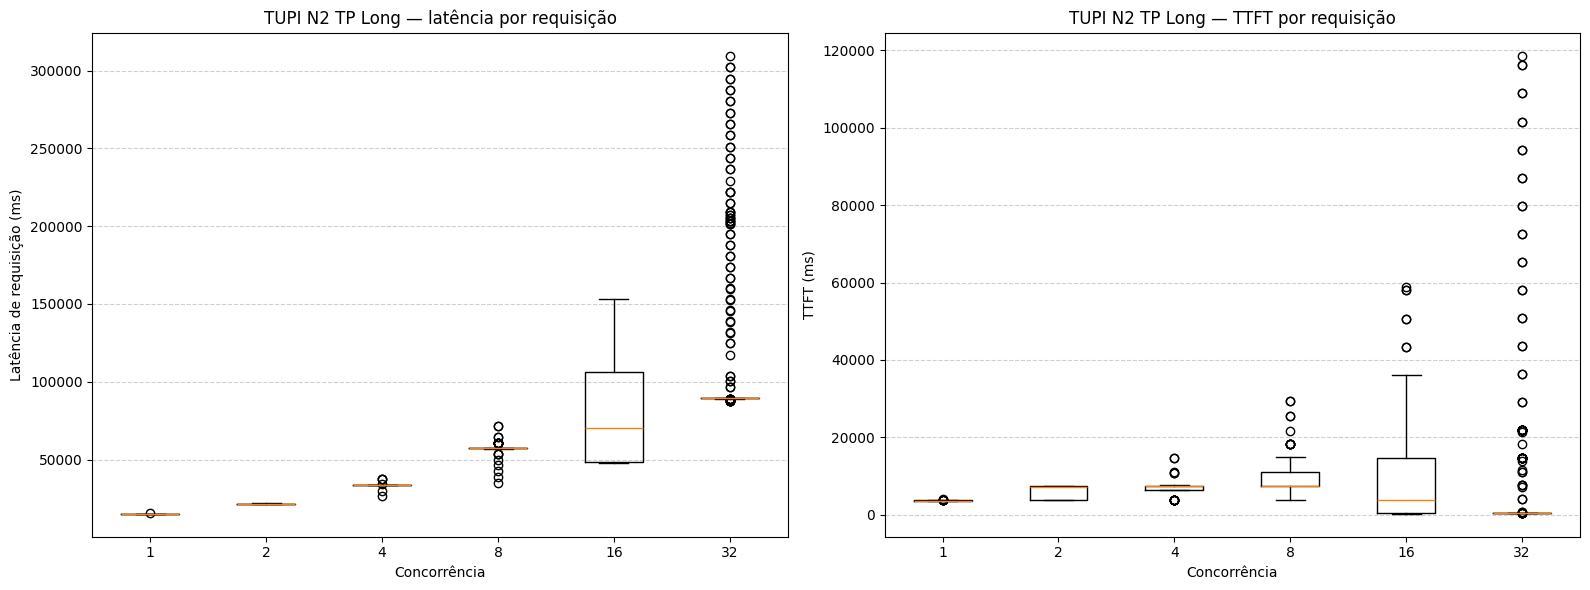

Saved: ../figures/concurrency_analysis/distribution-N2-tupi-TP-long-r1-795649.png


/tmp/nix-shell.U9xriO/ipykernel_565746/2745907445.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_lat.boxplot(lat_data, labels=[str(c) for c in concs], showfliers=True)


/tmp/nix-shell.U9xriO/ipykernel_565746/2745907445.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_ttft.boxplot(ttft_data, labels=[str(c) for c in tconcs], showfliers=True)


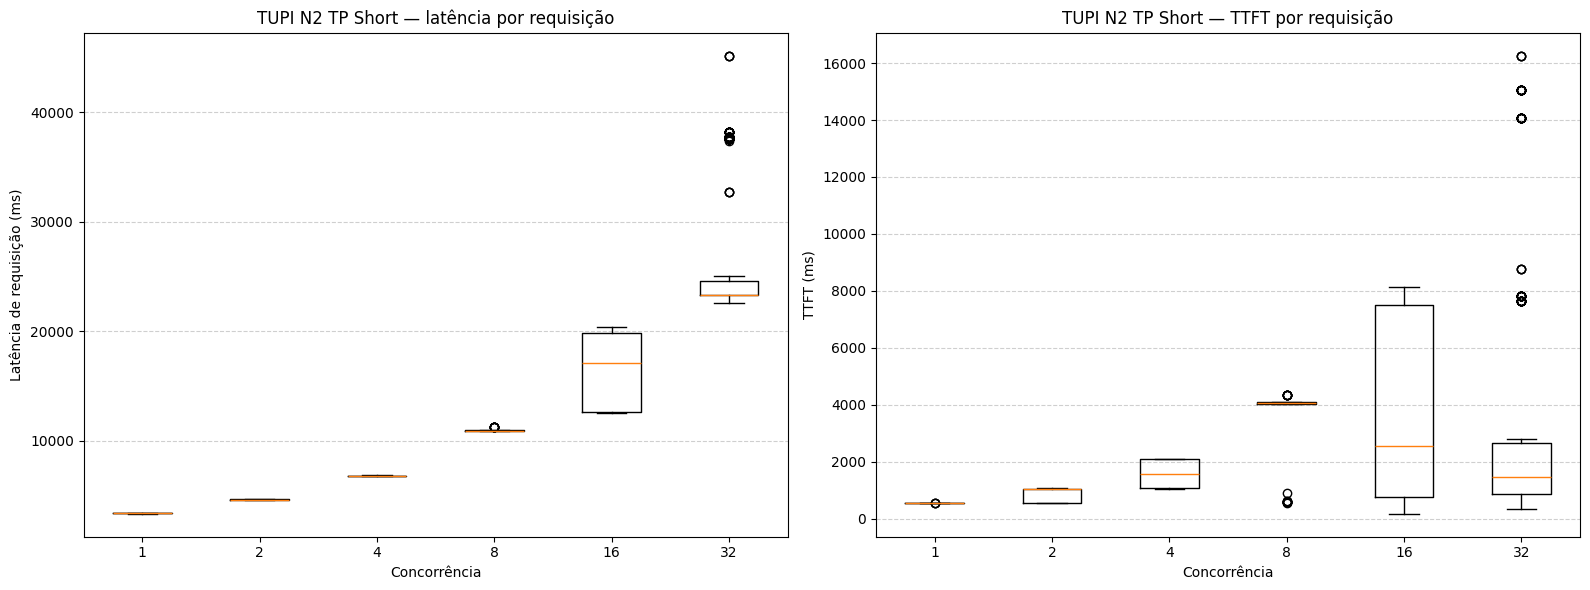

Saved: ../figures/concurrency_analysis/distribution-N2-tupi-TP-short-r1-796872.png


/tmp/nix-shell.U9xriO/ipykernel_565746/2745907445.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_lat.boxplot(lat_data, labels=[str(c) for c in concs], showfliers=True)
/tmp/nix-shell.U9xriO/ipykernel_565746/2745907445.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_ttft.boxplot(ttft_data, labels=[str(c) for c in tconcs], showfliers=True)


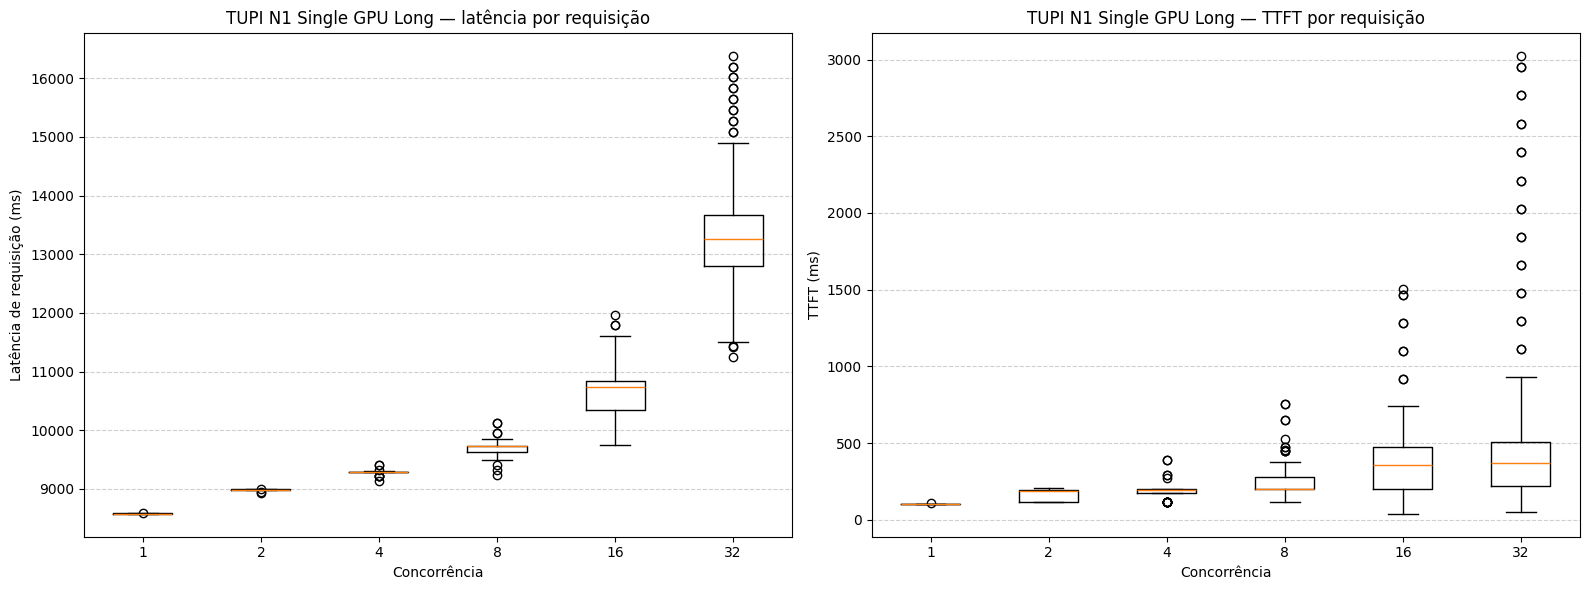

Saved: ../figures/concurrency_analysis/distribution-N1-tupi-none-long-r1-795502.png


/tmp/nix-shell.U9xriO/ipykernel_565746/2745907445.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_lat.boxplot(lat_data, labels=[str(c) for c in concs], showfliers=True)
/tmp/nix-shell.U9xriO/ipykernel_565746/2745907445.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_ttft.boxplot(ttft_data, labels=[str(c) for c in tconcs], showfliers=True)


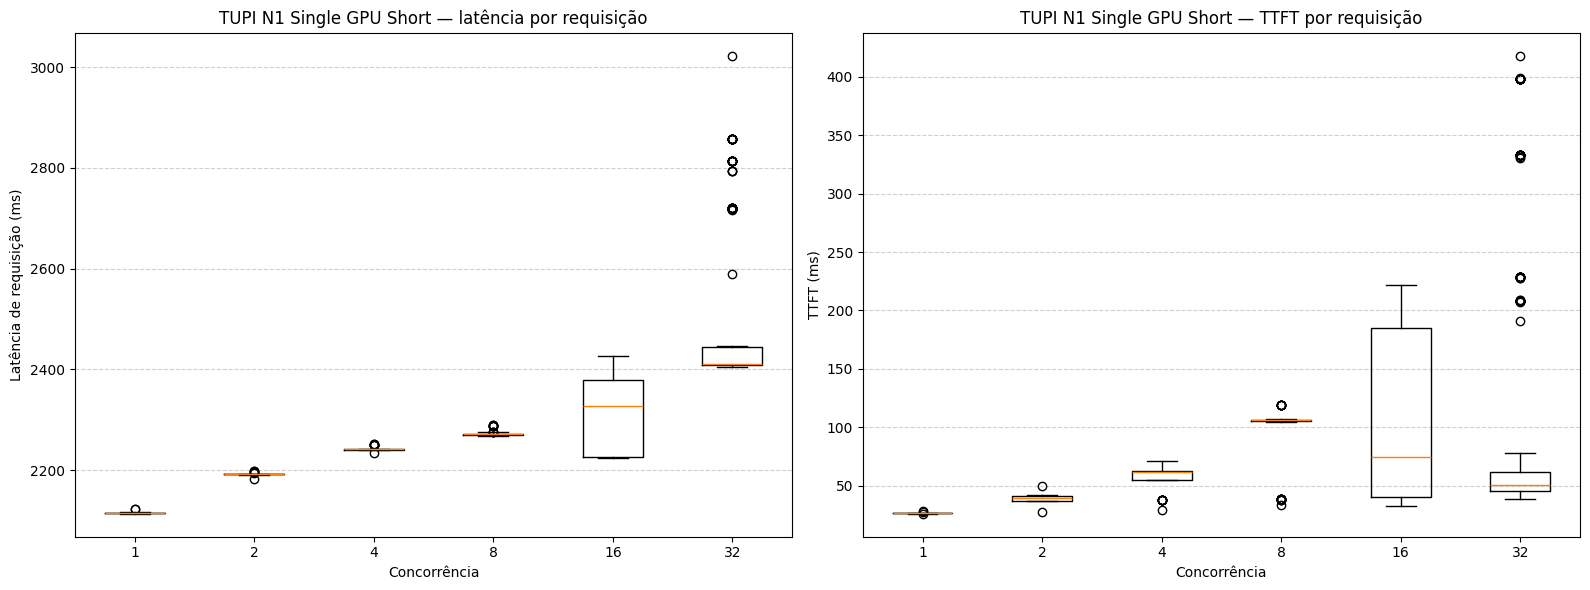

Saved: ../figures/concurrency_analysis/distribution-N1-tupi-none-short-r1-795503.png


In [18]:
def load_request_latencies(jsonl_path):
    jdf = load_jsonl_normalized(jsonl_path)
    if jdf.empty or 'request_latency.value' not in jdf.columns:
        return pd.Series(dtype=float)
    return pd.to_numeric(jdf['request_latency.value'], errors='coerce').dropna()


sample_experiments = (
    df.drop_duplicates('experiment_name')
      .sort_values(['node', 'strategy', 'workload', 'n_gpus'])
      ['experiment_name']
      .tolist()
)

for exp_name in sample_experiments:
    exp_df = df[df['experiment_name'] == exp_name].sort_values('concurrency')
    if exp_df.empty:
        continue

    label = exp_df['label'].iloc[0]
    latencies_by_conc = {}
    for _, row in exp_df.iterrows():
        series = load_request_latencies(row['jsonl_path'])
        if not series.empty:
            latencies_by_conc[int(row['concurrency'])] = series.values

    if not latencies_by_conc:
        continue

    concs = sorted(latencies_by_conc.keys())

    fig, (ax_lat, ax_ttft) = plt.subplots(1, 2, figsize=(16, 6))

    lat_data = [latencies_by_conc[c] for c in concs]
    ax_lat.boxplot(lat_data, labels=[str(c) for c in concs], showfliers=True)
    ax_lat.set_xlabel('Concorrência')
    ax_lat.set_ylabel('Latência de requisição (ms)')
    ax_lat.set_title(f'{label} — latência por requisição')
    ax_lat.grid(True, axis='y', linestyle='--', alpha=0.6)

    ttft_by_conc = {}
    for _, row in exp_df.iterrows():
        jdf = load_jsonl_normalized(row['jsonl_path'])
        if jdf.empty or 'time_to_first_token.value' not in jdf.columns:
            continue
        s = pd.to_numeric(jdf['time_to_first_token.value'], errors='coerce').dropna()
        if not s.empty:
            ttft_by_conc[int(row['concurrency'])] = s.values

    if ttft_by_conc:
        tconcs = sorted(ttft_by_conc.keys())
        ttft_data = [ttft_by_conc[c] for c in tconcs]
        ax_ttft.boxplot(ttft_data, labels=[str(c) for c in tconcs], showfliers=True)
        ax_ttft.set_xlabel('Concorrência')
        ax_ttft.set_ylabel('TTFT (ms)')
        ax_ttft.set_title(f'{label} — TTFT por requisição')
        ax_ttft.grid(True, axis='y', linestyle='--', alpha=0.6)
    else:
        ax_ttft.set_visible(False)

    plt.tight_layout()
    safe_name = exp_name.replace('_', '-')
    save_figure(f'distribution-{safe_name}.png')

### Speedup por concorrência (normalizado por c=1)

Para cada experimento, normaliza o throughput e a latência pelo menor nível de concorrência, evidenciando o ganho marginal de aumentar a concorrência.

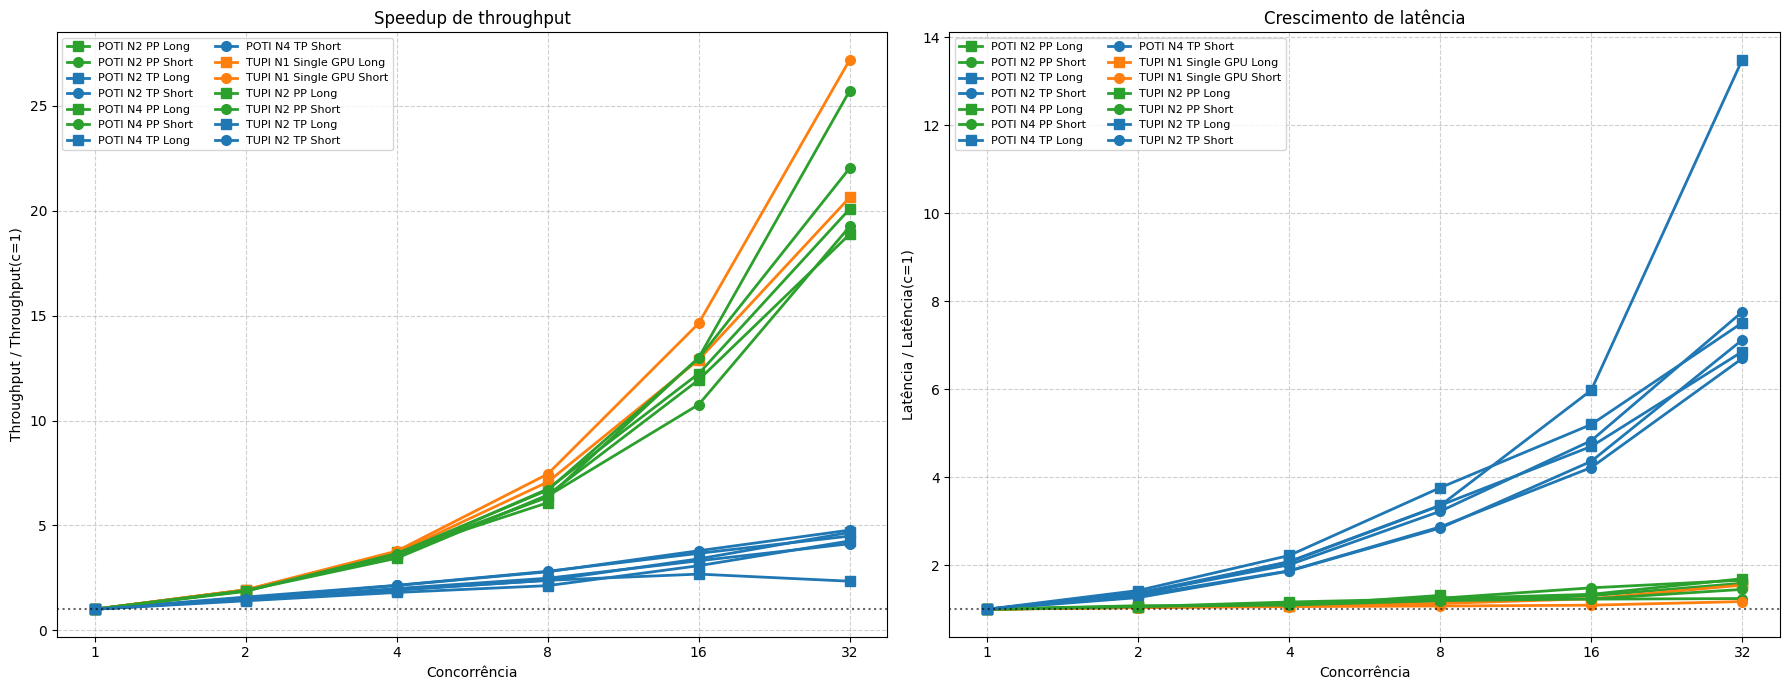

Saved: ../figures/concurrency_analysis/normalized-scaling.png


In [19]:
norm_rows = []
for label, sub in df.groupby('label'):
    sub = sub.sort_values('concurrency')
    base = sub[sub['concurrency'] == sub['concurrency'].min()]
    if base.empty:
        continue
    base_tput = base['request_throughput'].iloc[0]
    base_lat  = base['request_latency_avg'].iloc[0]
    if not base_tput:
        continue
    for _, row in sub.iterrows():
        norm_rows.append({
            'label':          label,
            'parallelism':    row['parallelism'],
            'workload':       row['workload'],
            'concurrency':    row['concurrency'],
            'throughput_ratio': row['request_throughput'] / base_tput,
            'latency_ratio':   (row['request_latency_avg'] / base_lat
                                if base_lat else np.nan),
        })

norm_df = pd.DataFrame(norm_rows)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

for label, sub in norm_df.groupby('label'):
    sub = sub.sort_values('concurrency')
    strat  = sub['parallelism'].iloc[0]
    wl     = sub['workload'].iloc[0]
    color  = strategy_color(strat)
    marker = WORKLOAD_MARKERS.get(wl, 'o')
    ax1.plot(sub['concurrency'], sub['throughput_ratio'],
             marker=marker, color=color, linewidth=2, markersize=7, label=label)
    ax2.plot(sub['concurrency'], sub['latency_ratio'],
             marker=marker, color=color, linewidth=2, markersize=7, label=label)

for ax, ylabel, title in [
    (ax1, 'Throughput / Throughput(c=1)', 'Speedup de throughput'),
    (ax2, 'Latência / Latência(c=1)',     'Crescimento de latência'),
]:
    ax.axhline(1.0, color='black', linestyle=':', alpha=0.6)
    ax.set_xscale('log', base=2)
    ax.set_xticks(sorted(norm_df['concurrency'].unique()))
    ax.set_xticklabels(sorted(norm_df['concurrency'].unique()))
    ax.set_xlabel('Concorrência')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, which='both', linestyle='--', alpha=0.6)
    ax.legend(loc='best', fontsize=8, ncol=2)

plt.tight_layout()
save_figure('normalized-scaling.png')

Mais uma vez, os experimentos que utilizam o TP mostrar pior desempenho geral.

### Resumo

Mostra, em formato tabular, o throughput máximo e a concorrência onde ele foi atingido para cada experimento — útil para identificar o ponto ótimo de operação de cada configuração.

In [20]:
summary = (
    df.loc[df.groupby('experiment_name')['request_throughput'].idxmax()]
      [['label', 'parallelism', 'workload', 'concurrency',
        'request_throughput', 'request_latency_avg', 'ttft_avg',
        'inter_token_latency_avg']]
      .sort_values(['parallelism', 'workload', 'label'])
      .reset_index(drop=True)
)
summary.rename(columns={
    'concurrency':              'conc_otimo',
    'request_throughput':       'throughput_max (req/s)',
    'request_latency_avg':      'latencia_avg (ms)',
    'ttft_avg':                 'ttft_avg (ms)',
    'inter_token_latency_avg':  'itl_avg (ms)',
}, inplace=True)
summary

,label,parallelism,workload,conc_otimo,throughput_max (req/s),latencia_avg (ms),ttft_avg (ms),itl_avg (ms)
0,POTI N2 PP Long,PP,long,32,1.141265,28012.928825,1489.418674,52.391040
1,POTI N4 PP Long,PP,long,8,0.315776,25323.183543,2053.889496,45.734325
2,TUPI N2 PP Long,PP,long,32,1.851494,17267.807414,477.090566,33.154051
3,POTI N2 PP Short,PP,short,32,5.952929,5371.491381,249.619070,40.355196
4,POTI N4 PP Short,PP,short,32,4.079220,7836.140408,558.873357,57.515810
5,TUPI N2 PP Short,PP,short,32,8.925752,3580.197290,210.675906,26.534274
6,TUPI N1 Single GPU Long,Single GPU,long,32,2.404178,13288.157928,479.811433,25.312144
7,TUPI N1 Single GPU Short,Single GPU,short,32,12.848802,2486.172644,93.514645,18.843587
8,POTI N2 TP Long,TP,long,16,0.143253,111651.704343,16008.958428,188.740608
9,POTI N4 TP Long,TP,long,32,0.187005,171019.091252,13415.931485,311.501453


### Grupo D — Comunicação como vilão na saturação

Dois painéis focados na tese de comunicação, no regime de saturação:
1. **Throughput no ponto de saturação (c=32)**: single-GPU (TUPI) domina; PP > TP em
   todas as células — o AllReduce frequente do TP não se recupera nem com batching.
2. **Razão PP/TP ao longo da concorrência**: se comunicação é o vilão, PP deve ficar
   consistentemente à frente do TP em todos os níveis (a razão não cai com batching).

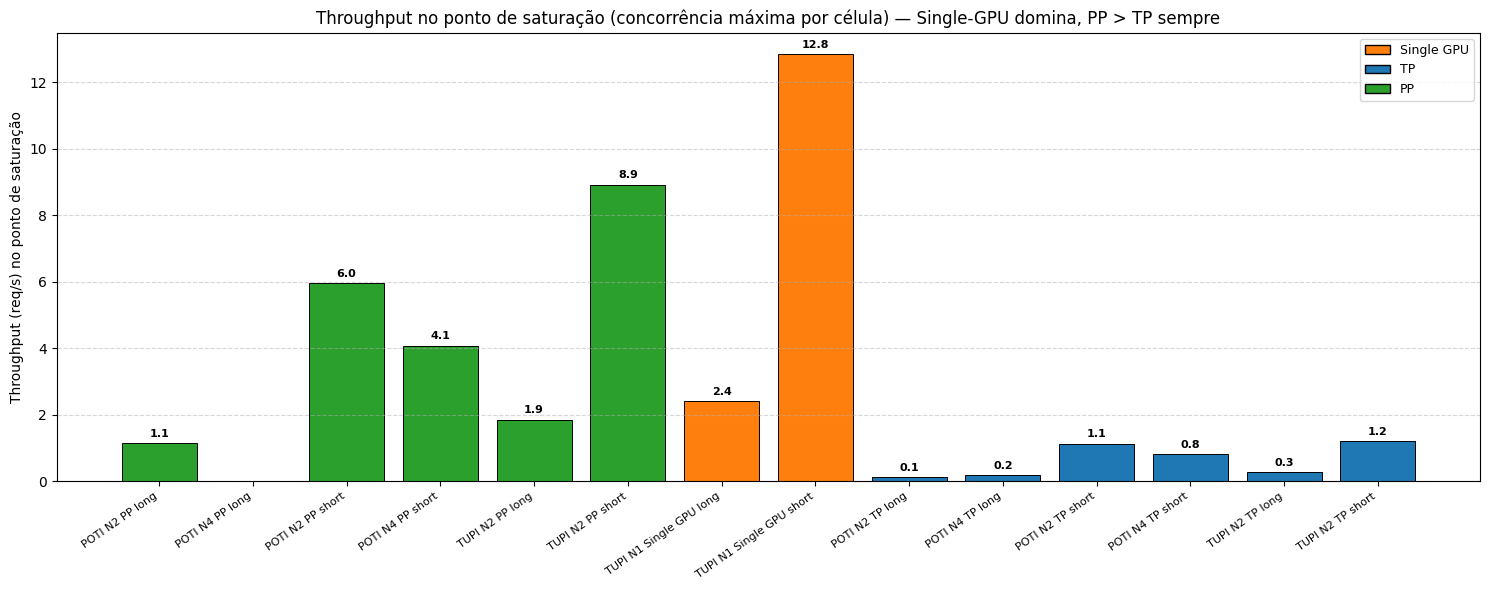

Saved: ../figures/concurrency_analysis/grupoD-saturation-throughput.png


In [21]:
# (1) Throughput no ponto de saturação (maior concorrência disponível por célula)
peak_conc = df.groupby('experiment_name')['concurrency'].max().reset_index()
peak = peak_conc.merge(df, on=['experiment_name', 'concurrency'])
peak = peak.sort_values(['parallelism', 'node', 'workload', 'n_gpus']).reset_index(drop=True)
peak['cell'] = peak.apply(lambda r: f"{r['node'].upper()} N{r['n_gpus']} {r['parallelism']} {r['workload']}", axis=1)

fig, ax = plt.subplots(figsize=(15, 6))
x = np.arange(len(peak))
colors = [STRATEGY_COLORS.get(s, 'gray') for s in peak['parallelism']]
ax.bar(x, peak['request_throughput'], color=colors, edgecolor='black', linewidth=0.7)
for i, v in enumerate(peak['request_throughput']):
    ax.text(i, v + peak['request_throughput'].max()*0.01, f'{v:.1f}',
            ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(peak['cell'], rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Throughput (req/s) no ponto de saturação')
ax.set_title(f'Throughput no ponto de saturação (concorrência máxima por célula) — Single-GPU domina, PP > TP sempre')
handles = [Patch(facecolor=STRATEGY_COLORS[s], edgecolor='black', label=s) for s in STRATEGY_ORDER]
ax.legend(handles=handles, fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
pathD1 = FIGURES_DIR / 'grupoD-saturation-throughput.png'
plt.savefig(pathD1, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {pathD1}")

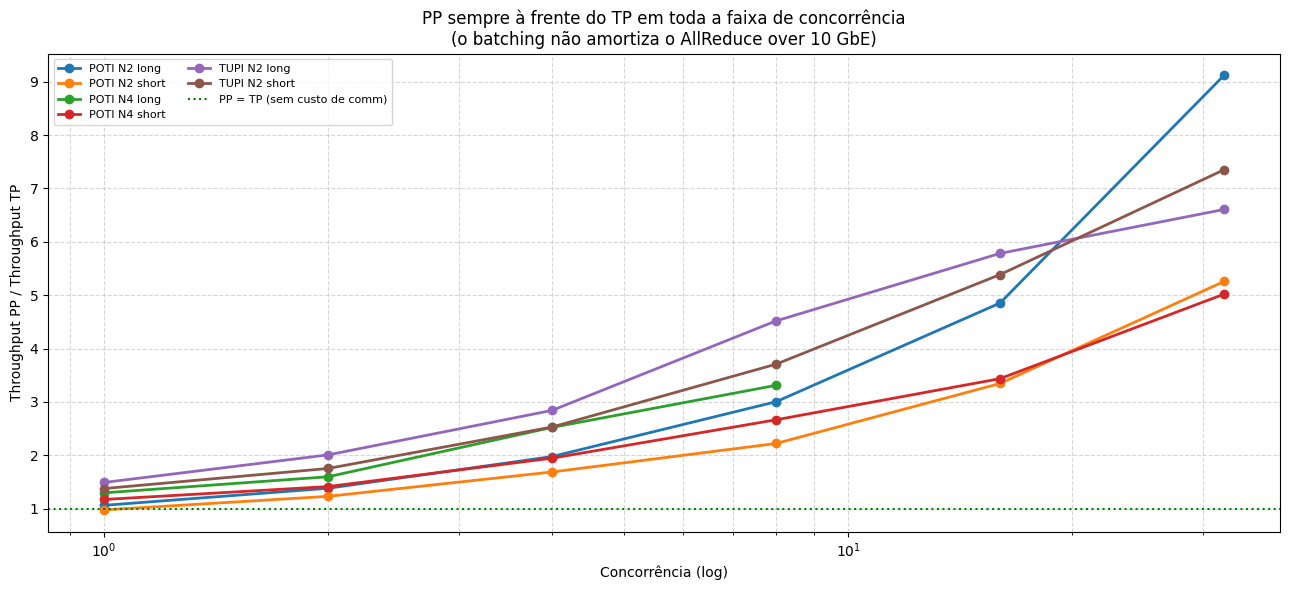

Saved: ../figures/concurrency_analysis/grupoD-pp-over-tp-ratio.png

Mediana da razão PP/TP por célula (>1 = PP ganha do TP em toda a curva):
cell
POTI N2 long     2.49
POTI N2 short    1.95
POTI N4 long     2.06
POTI N4 short    2.30
TUPI N2 long     3.68
TUPI N2 short    3.12


In [22]:
# (2) Razão PP/TP ao longo da concorrência (células pareadas por nó/N/workload).
ratio_rows = []
for (node, ng, wl), grp in df.groupby(['node', 'n_gpus', 'workload']):
    tp = grp[grp['strategy'] == 'TP'].sort_values('concurrency')
    pp = grp[grp['strategy'] == 'PP'].sort_values('concurrency')
    merged = tp.merge(pp, on='concurrency', suffixes=('_tp', '_pp'))
    for _, r in merged.iterrows():
        ratio_rows.append({
            'concurrency': r['concurrency'],
            'ratio': r['request_throughput_pp'] / r['request_throughput_tp']
                    if r['request_throughput_tp'] else np.nan,
            'cell': f"{node.upper()} N{ng} {wl}",
        })
ratio_df = pd.DataFrame(ratio_rows)

fig, ax = plt.subplots(figsize=(13, 6))
for cell, sub in ratio_df.groupby('cell'):
    sub = sub.sort_values('concurrency')
    ax.plot(sub['concurrency'], sub['ratio'], marker='o', linewidth=2, markersize=6, label=cell)
ax.axhline(1, color='green', linestyle=':', linewidth=1.5, label='PP = TP (sem custo de comm)')
ax.set_xscale('log')
ax.set_xlabel('Concorrência (log)')
ax.set_ylabel('Throughput PP / Throughput TP')
ax.set_title('PP sempre à frente do TP em toda a faixa de concorrência\n'
             '(o batching não amortiza o AllReduce over 10 GbE)')
ax.legend(fontsize=8, ncol=2)
ax.grid(linestyle='--', alpha=0.5, which='both')
plt.tight_layout()
pathD2 = FIGURES_DIR / 'grupoD-pp-over-tp-ratio.png'
plt.savefig(pathD2, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {pathD2}")

print()
print('Mediana da razão PP/TP por célula (>1 = PP ganha do TP em toda a curva):')
print(ratio_df.groupby('cell')['ratio'].median().round(2).to_string())